# FINTECH Final Project — Bank Marketing Classification

**Course:** `[2025-2026] - 055643 - FINTECH`  
**Student:** Salvatore Mariano Librici  
**Dataset:** `Dataset4.csv` — Bank Marketing  

## Project goal

The goal of this notebook is to build a Machine Learning pipeline to estimate the probability that a client subscribes a bank term deposit after a direct marketing campaign.

The work is structured as follows:

1. Data loading and quality checks  
2. Exploratory Data Analysis  
3. Preprocessing  
4. Baseline model  
5. Logistic Regression  
6. Random Forest  
7. Model comparison  
8. Feature selection  
9. Interpretability  
10. Final business conclusions  

> The notebook is written to show both technical implementation and the reasoning process behind the analysis.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Colab setup

Expected dataset path:

```text
/content/[2025-2026] - 055643 - FINTECH - PROJECT/Dataset4.csv
```

If the dataset is directly uploaded into Colab, the notebook also tries:

```text
/content/Dataset4.csv
```

In [2]:
# ============================================================
# 0. COLAB SETUP
# ============================================================

import os
from pathlib import Path

PROJECT_FOLDER = "/content/[2025-2026] - 055643 - FINTECH - PROJECT"
DATASET_NAME = "Dataset4.csv"

DATASET_PATH = os.path.join(PROJECT_FOLDER, DATASET_NAME)

# Fallback if the file is uploaded directly to /content
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = f"/content/{DATASET_NAME}"

# Fallback if the file is uploaded to /content/content
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = f"/content/content/{DATASET_NAME}"

# Fallback for Google Drive path
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = f"/content/drive/MyDrive/[2025-2026] - 055643 - FINTECH - PROJECT/content/{DATASET_NAME}"

print("Dataset path used:", DATASET_PATH)
print("File exists:", os.path.exists(DATASET_PATH))

Dataset path used: /content/drive/MyDrive/[2025-2026] - 055643 - FINTECH - PROJECT/content/Dataset4.csv
File exists: True


## 1. Import libraries

Libraries for data manipulation, visualization, preprocessing, modeling, evaluation and interpretability.

In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP is not installed. Run this cell if needed: !pip install shap")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load dataset

We load the dataset and inspect the first rows.

In [4]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(DATASET_PATH, sep=';')

display(df.head())
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Dataset shape: 45211 rows and 17 columns


## 3. Initial data overview

We inspect:

- column names  
- data types  
- number of non-null observations  
- descriptive statistics  

This gives a first understanding of numerical and categorical predictors.

In [5]:
# ============================================================
# 3. INITIAL DATA OVERVIEW
# ============================================================

print("Column names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcom

In [6]:
# Descriptive statistics for numerical variables
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [7]:
# Descriptive statistics for categorical variables
display(df.describe(include="object").T)

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


### Initial observations

Complete this cell after execution:

- The dataset contains `...` observations and `...` variables.
- The target variable is `y`.
- There are both numerical and categorical variables.
- Some categorical variables may contain values such as `unknown`.

## 4. Data quality checks

Before modeling, we check:

1. missing values  
2. duplicate rows  
3. `"unknown"` values in categorical variables  
4. basic target consistency

In [8]:
# ============================================================
# 4. DATA QUALITY CHECKS
# ============================================================

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("Missing values:")
display(missing_values if len(missing_values) > 0 else "No missing values found.")

Missing values:


'No missing values found.'

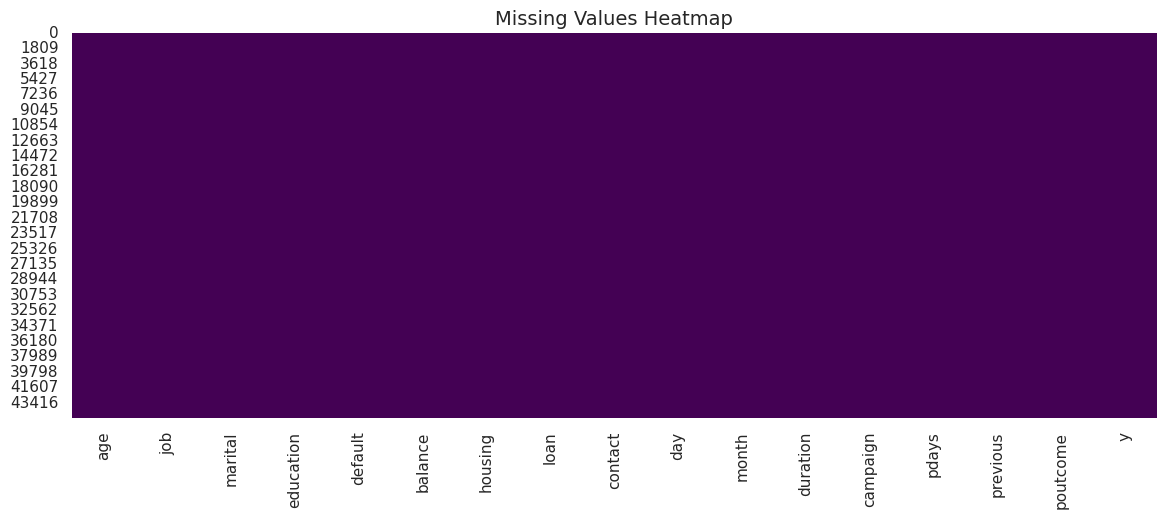

In [9]:
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [10]:
duplicates = df.duplicated().sum()
print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [11]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

unknown_summary = {}
for col in categorical_columns:
    unknown_summary[col] = (df[col] == "unknown").sum()

unknown_summary = pd.Series(unknown_summary).sort_values(ascending=False)
display(unknown_summary[unknown_summary > 0])

,0
poutcome,36959
contact,13020
education,1857
job,288


### Data quality interpretation

In this notebook, `"unknown"` values are initially kept as a separate category.  
This may be reasonable in banking data because missing information can itself be informative.

Duplicated rows should be inspected carefully. If they are exact duplicates and not meaningful repeated records, they may be removed. For now, we keep the original data unless duplicates clearly create problems.

## 5. Target variable analysis

The target variable is:

- `yes`: client subscribed the term deposit  
- `no`: client did not subscribe the term deposit  

We inspect class balance before selecting metrics and models.

In [12]:
# ============================================================
# 5. TARGET VARIABLE ANALYSIS
# ============================================================

target_counts = df["y"].value_counts()
target_percentages = (df["y"].value_counts(normalize=True) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

display(target_summary)

,count,percentage
y,,
no,39922,88.3
yes,5289,11.7


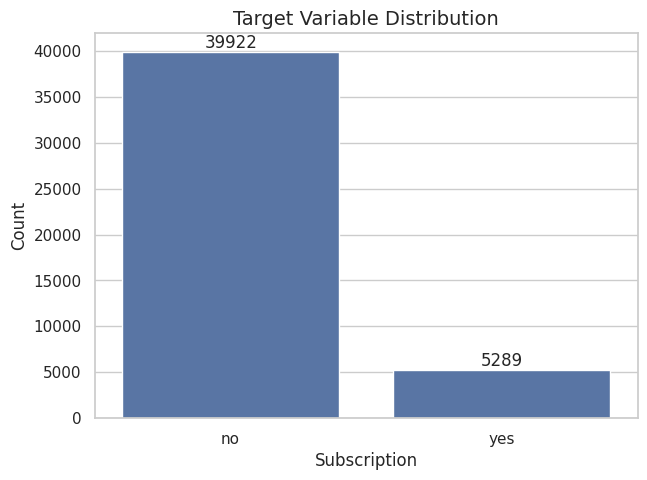

In [13]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="y", order=target_counts.index)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

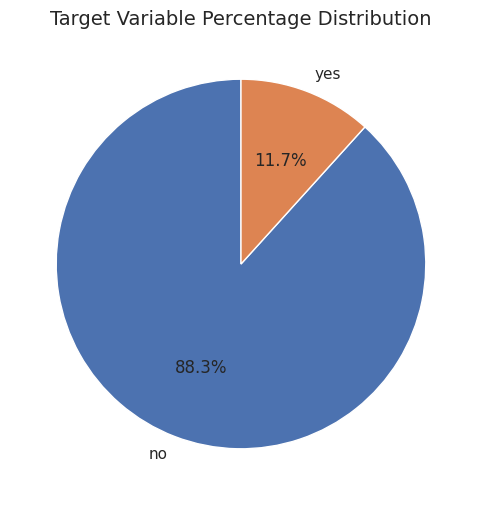

In [14]:
plt.figure(figsize=(6, 6))
plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Target Variable Percentage Distribution")
plt.show()

### Target interpretation

Complete after execution:

- The target variable is balanced / moderately imbalanced / strongly imbalanced.
- Accuracy alone may be misleading if the target is imbalanced.
- We will therefore evaluate precision, recall, F1-score, ROC-AUC and PR-AUC.

## 6. Numerical feature analysis

We inspect the distribution of numerical variables to detect skewness, extreme values and possible scaling needs.

In [15]:
# ============================================================
# 6. NUMERICAL FEATURE ANALYSIS
# ============================================================

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [col for col in df.select_dtypes(include="object").columns.tolist() if col != "y"]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


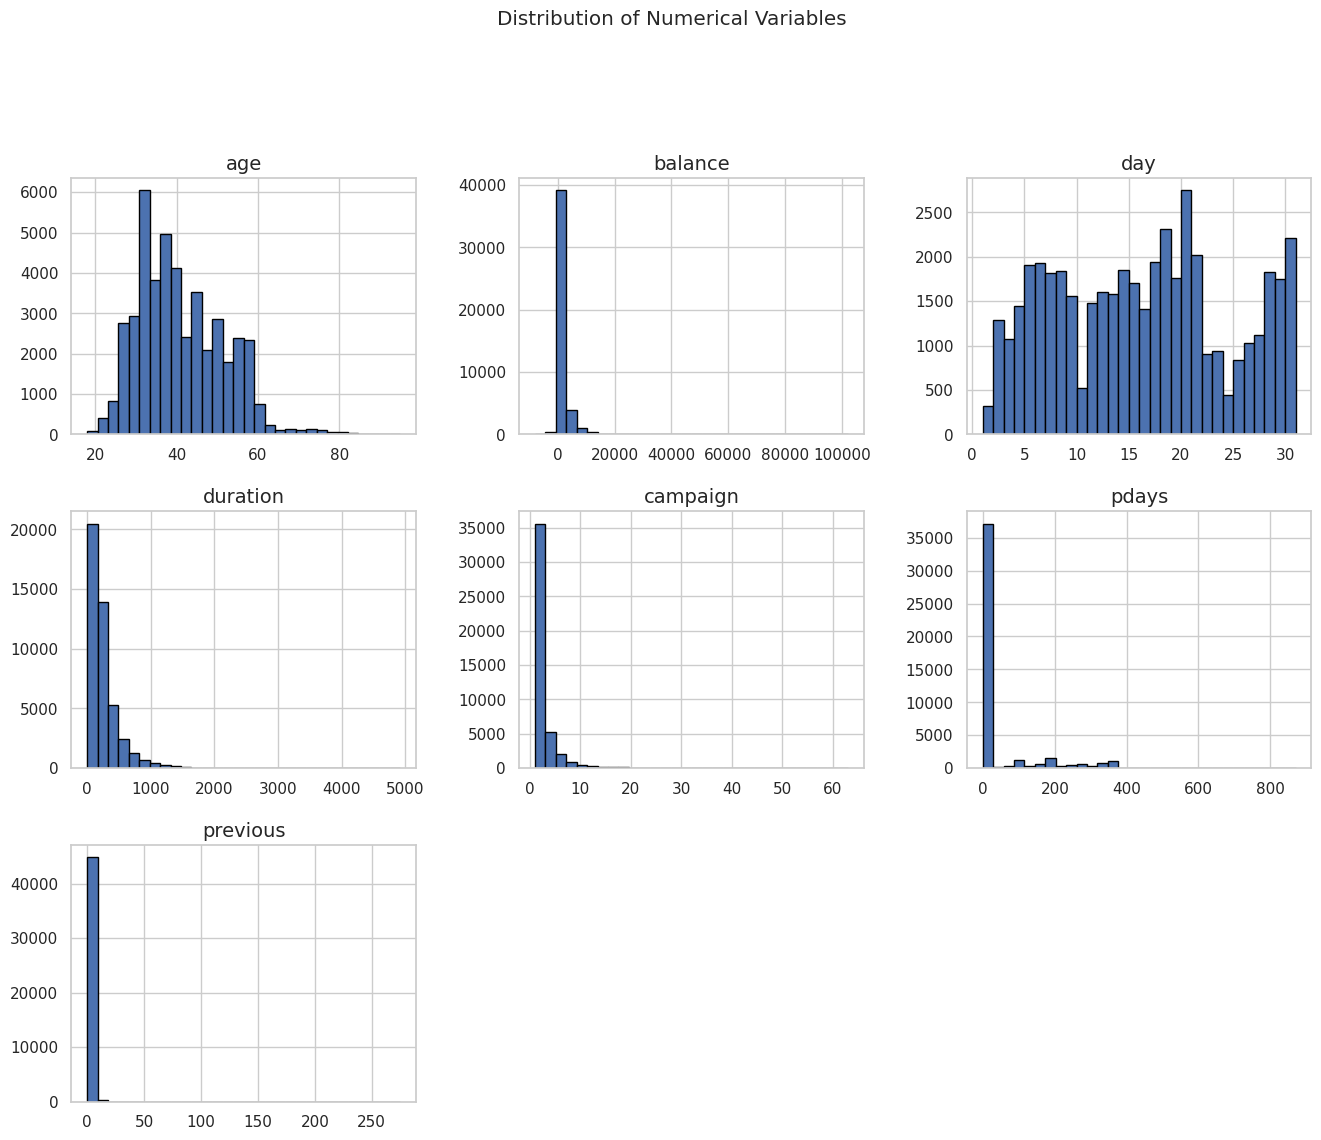

In [16]:
df[num_cols].hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Variables", y=1.02)
plt.show()

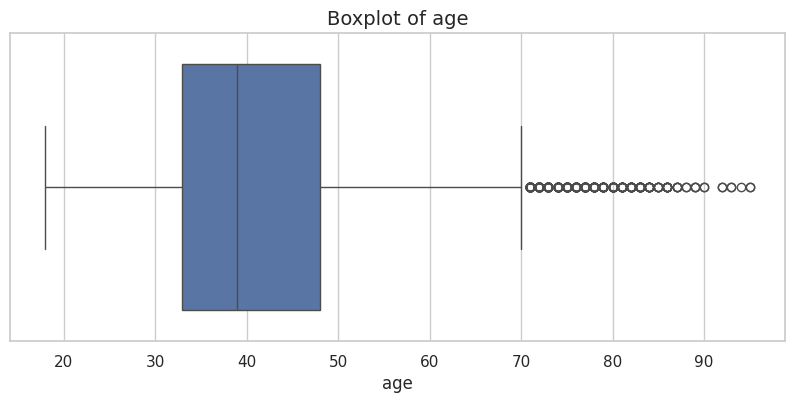

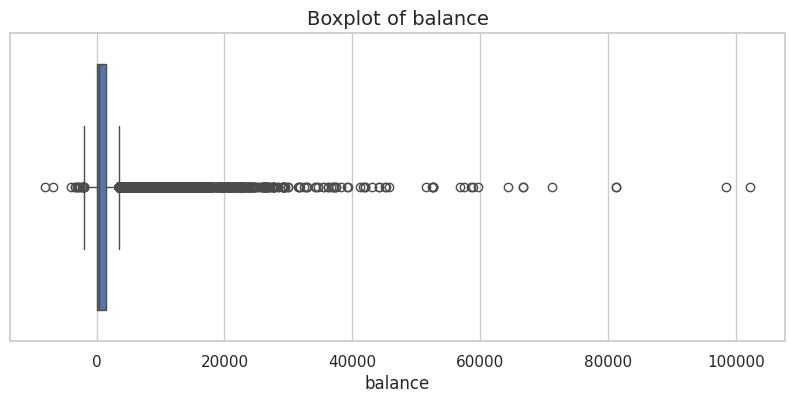

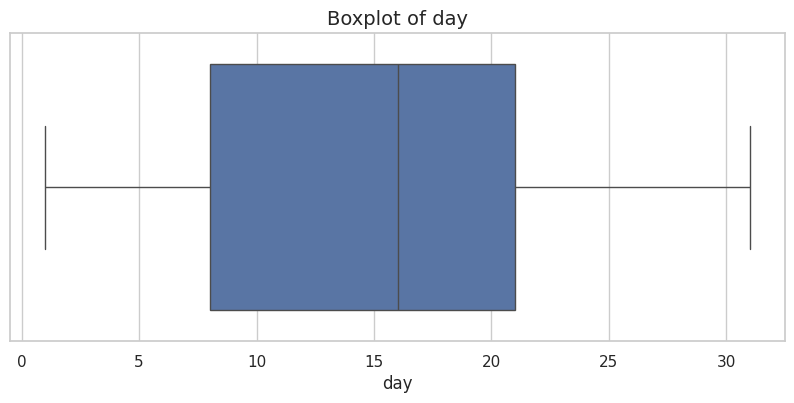

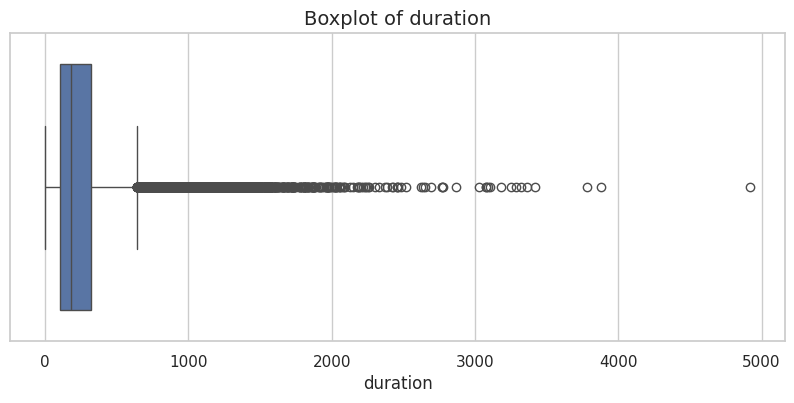

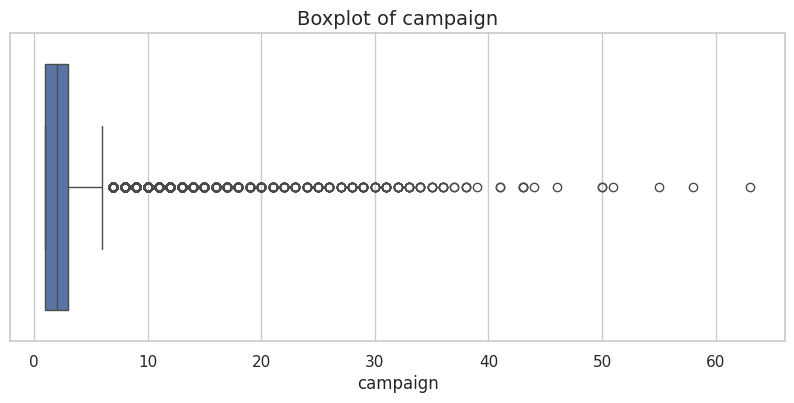

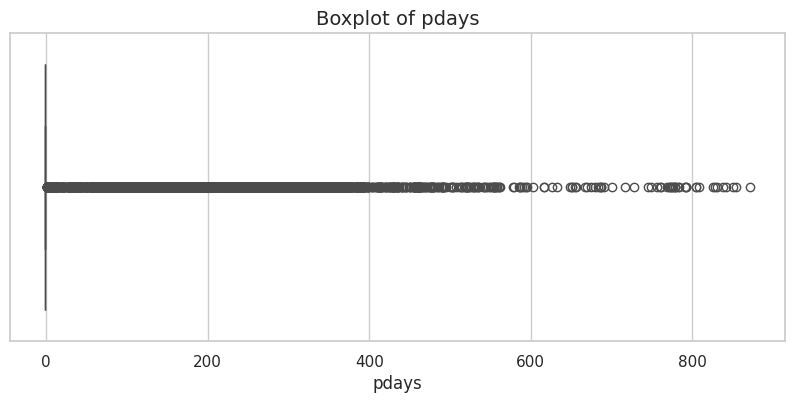

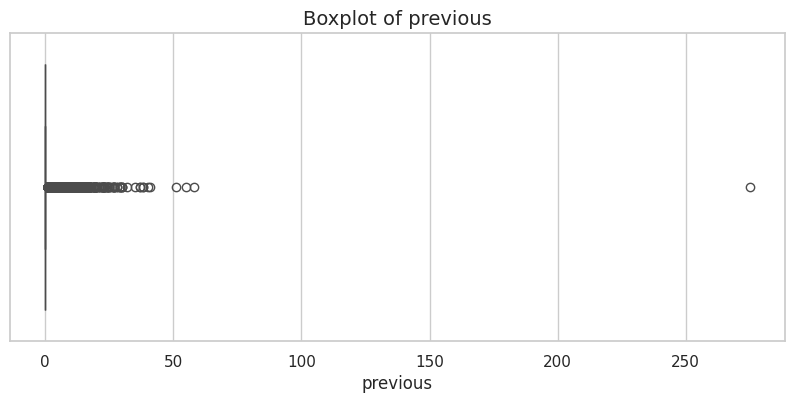

In [17]:
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [18]:
skewness = df[num_cols].skew().sort_values(ascending=False)
display(pd.DataFrame({"skewness": skewness}))

,skewness
previous,41.846454
balance,8.360308
campaign,4.898650
duration,3.144318
pdays,2.615715
age,0.684818
day,0.093079


### Numerical feature interpretation

Possible comments:

- `balance`, `duration`, and `campaign` may be skewed.
- Outliers can exist in financial and campaign variables.
- Logistic Regression benefits from scaling.
- Random Forest is less sensitive to scaling and monotonic transformations.

## 7. Numerical variables vs target

We compare numerical features across subscribed and non-subscribed clients.

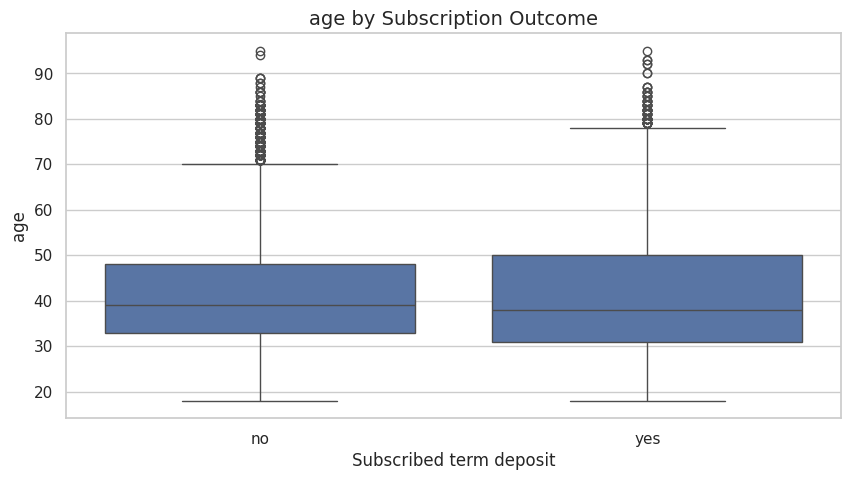

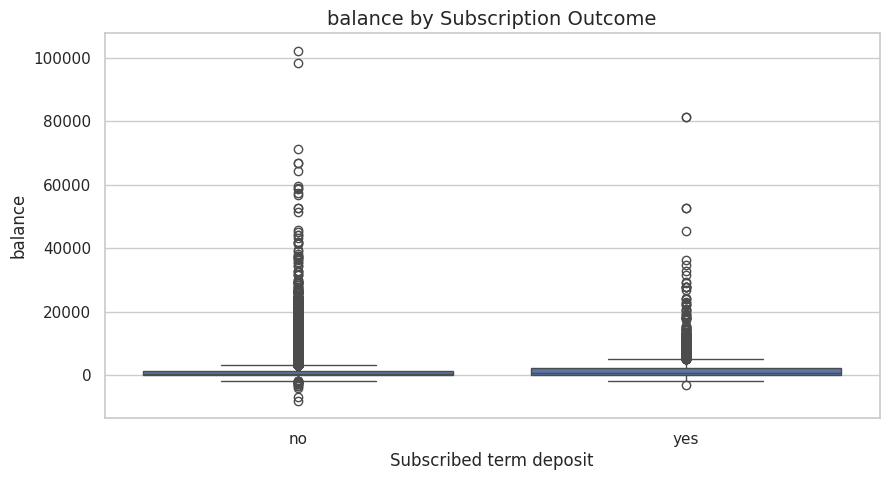

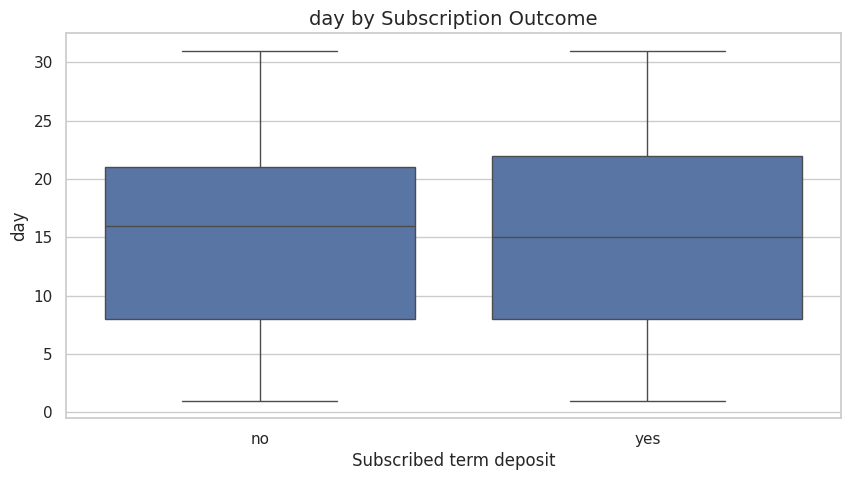

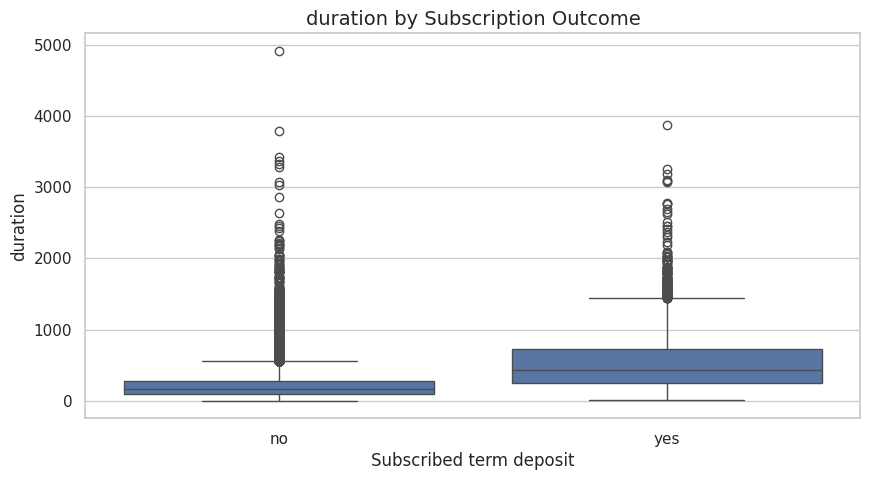

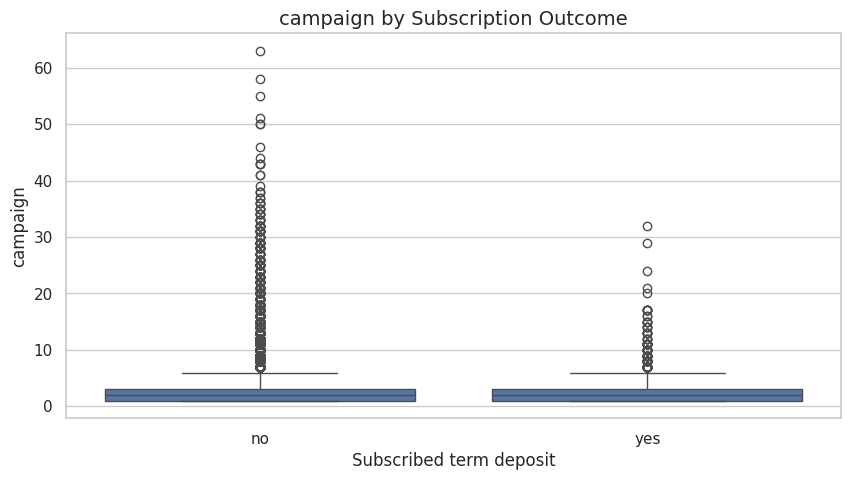

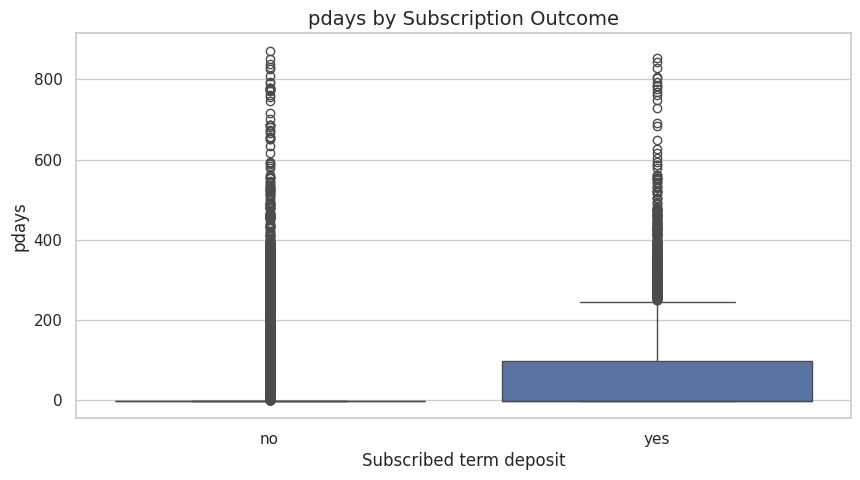

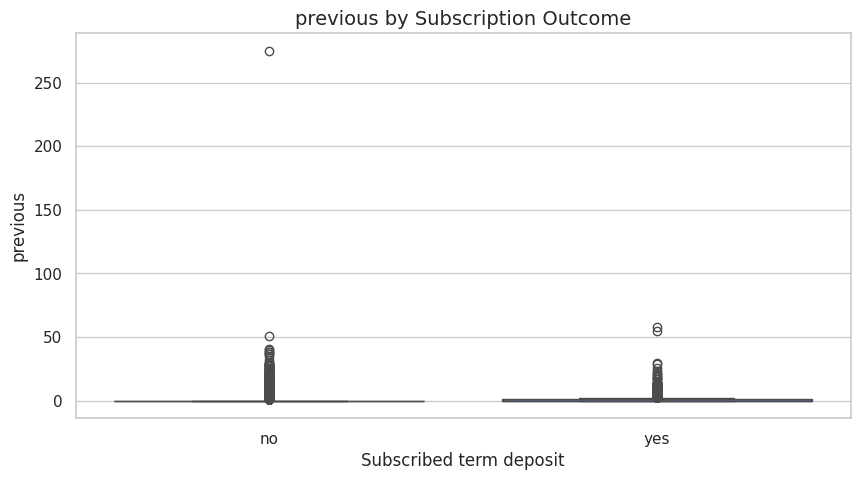

In [19]:
# ============================================================
# 7. NUMERICAL VARIABLES VS TARGET
# ============================================================

for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="y", y=col)
    plt.title(f"{col} by Subscription Outcome")
    plt.xlabel("Subscribed term deposit")
    plt.ylabel(col)
    plt.show()

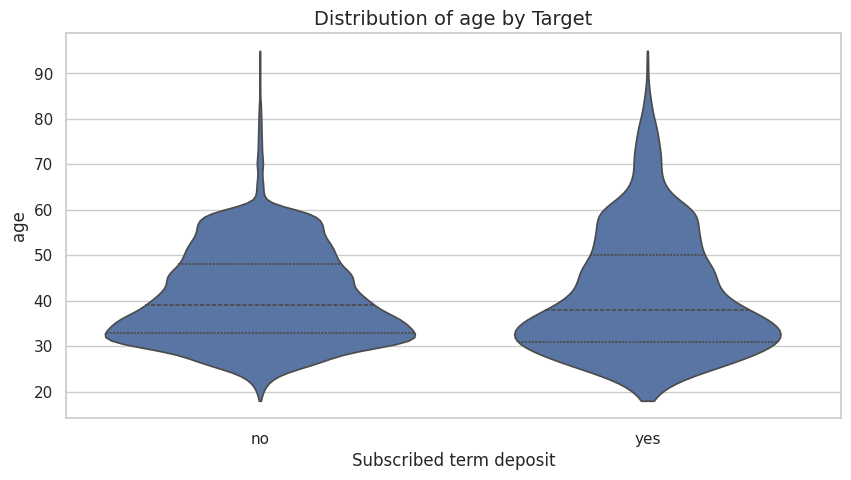

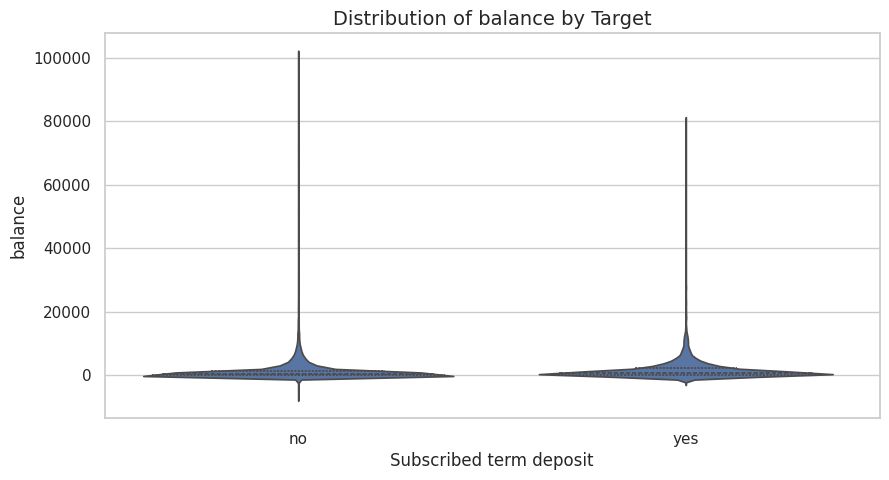

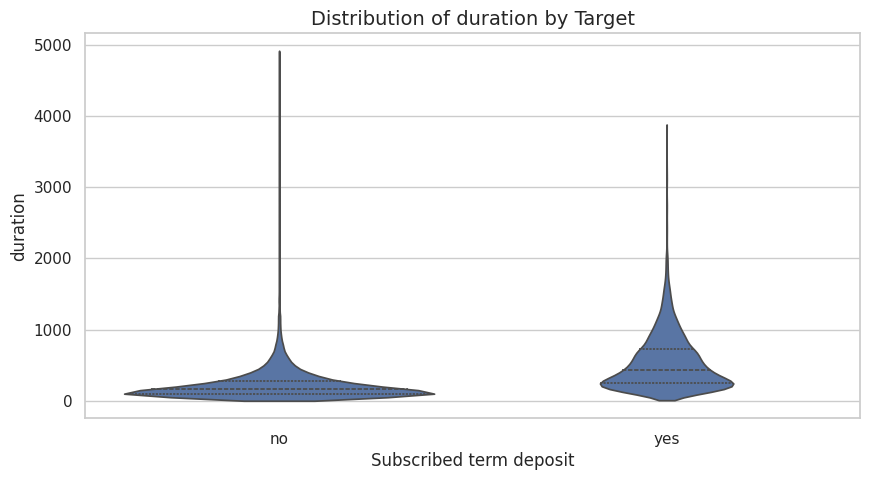

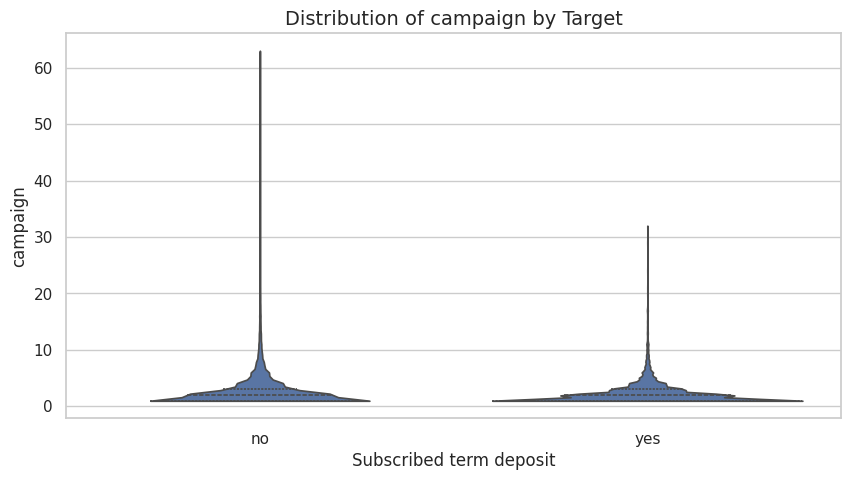

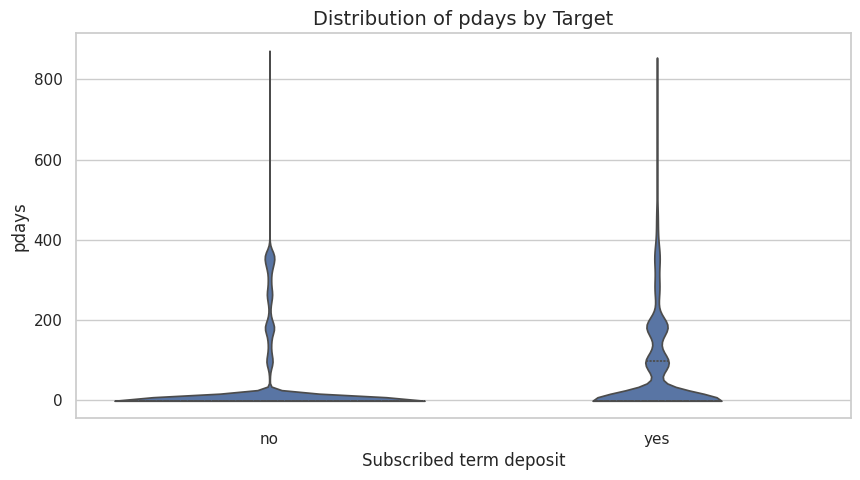

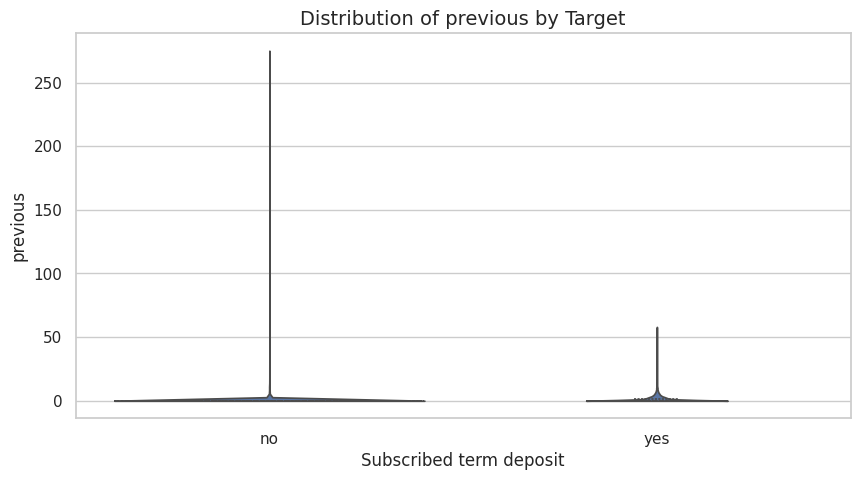

In [20]:
selected_num_cols = [col for col in ["age", "balance", "duration", "campaign", "pdays", "previous"] if col in df.columns]

for col in selected_num_cols:
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x="y", y=col, inner="quartile", cut=0)
    plt.title(f"Distribution of {col} by Target")
    plt.xlabel("Subscribed term deposit")
    plt.ylabel(col)
    plt.show()

In [21]:
median_by_target = df.groupby("y")[num_cols].median().T
display(median_by_target)

y,no,yes
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


### Important methodological note on `duration`

The variable `duration` represents the duration of the last contact.

It is usually very predictive because longer calls are naturally associated with higher subscription probability. However, it is only known after the call occurs.

Therefore:

- it is useful if the goal is to predict the final result after a call;
- it may be problematic if the goal is to decide whom to call before the campaign.

For robustness, this notebook includes an optional comparison with and without `duration`.

## 8. Categorical feature analysis

We analyze categorical variables using both frequency tables and subscription rates.

In [22]:
# ============================================================
# 8. CATEGORICAL FEATURE ANALYSIS
# ============================================================

for col in cat_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts().to_frame("count").head(20))


Column: job


,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303



Column: marital


,count
marital,
married,27214
single,12790
divorced,5207



Column: education


...

,count
contact,
cellular,29285
unknown,13020
telephone,2906



Column: month


,count
month,
may,13766
jul,6895
aug,6247
jun,5341
nov,3970
apr,2932
feb,2649
jan,1403
oct,738



Column: poutcome


,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


In [23]:
def plot_subscription_rate_by_category(data, column, target="y", min_count=0):
    # Plot subscription rate by category.
    temp = data.copy()

    counts = temp[column].value_counts()
    valid_categories = counts[counts >= min_count].index
    temp = temp[temp[column].isin(valid_categories)]

    rate = (
        temp.groupby(column)[target]
        .apply(lambda x: (x == "yes").mean())
        .sort_values(ascending=False)
    )

    count = temp[column].value_counts().loc[rate.index]

    result = pd.DataFrame({
        "subscription_rate": rate,
        "count": count
    })

    plt.figure(figsize=(12, 5))
    sns.barplot(x=result.index, y=result["subscription_rate"])
    plt.title(f"Subscription Rate by {column}")
    plt.ylabel("Subscription rate")
    plt.xlabel(column)
    plt.xticks(rotation=45, ha="right")
    plt.show()

    display(result)

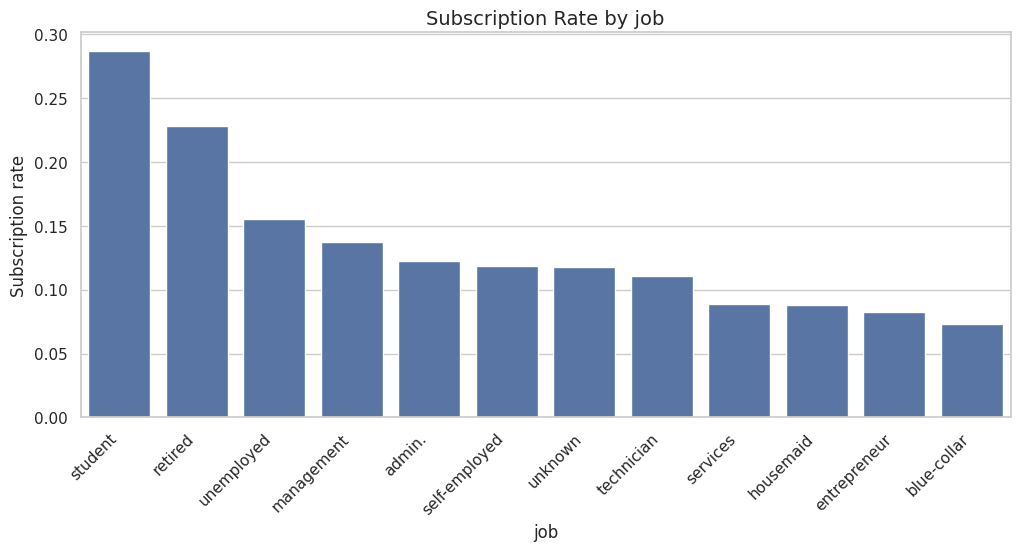

,subscription_rate,count
job,,
student,0.286780,938
retired,0.227915,2264
unemployed,0.155027,1303
management,0.137556,9458
admin.,0.122027,5171
self-employed,0.118429,1579
unknown,0.118056,288
technician,0.110570,7597
services,0.088830,4154


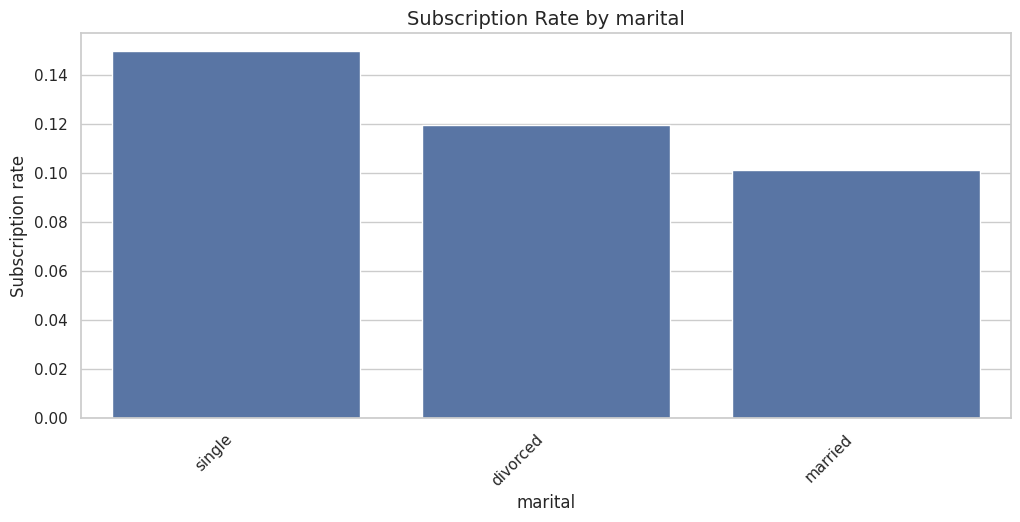

,subscription_rate,count
marital,,
single,0.149492,12790
divorced,0.119455,5207
married,0.101235,27214


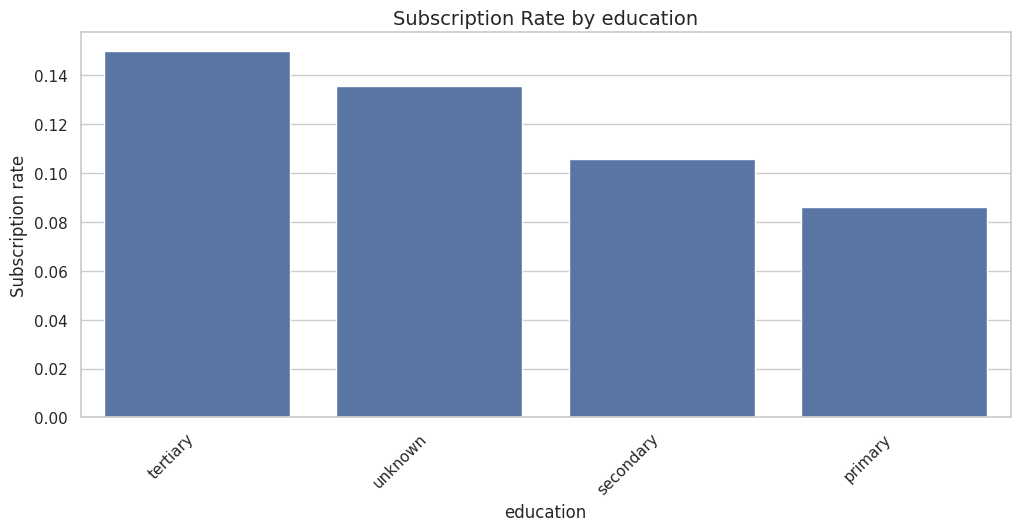

,subscription_rate,count
education,,
tertiary,0.150064,13301
unknown,0.135703,1857
secondary,0.105594,23202
primary,0.086265,6851


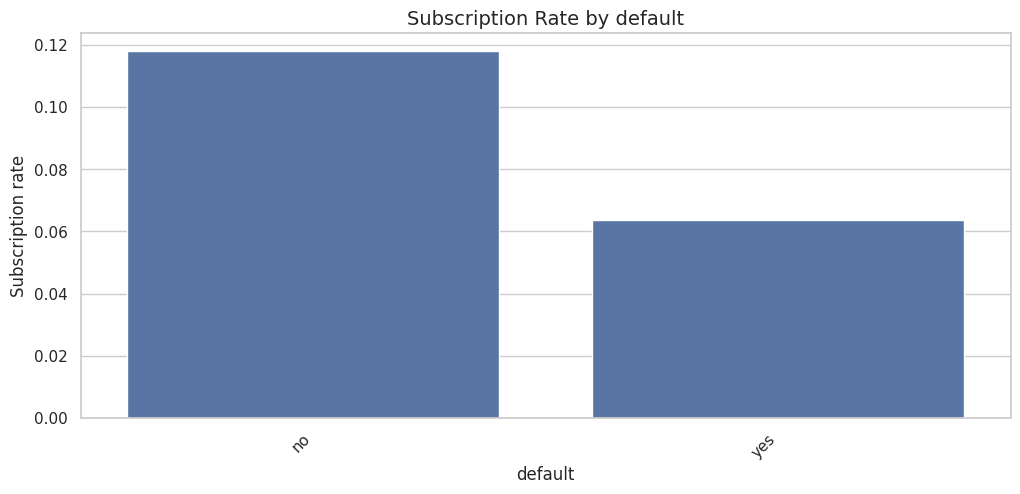

,subscription_rate,count
default,,
no,0.117961,44396
yes,0.063804,815


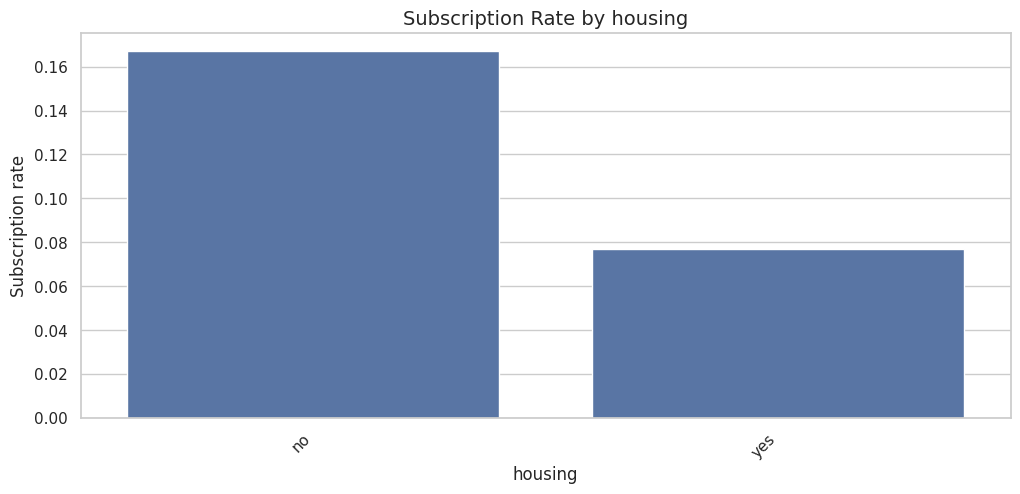

,subscription_rate,count
housing,,
no,0.167024,20081
yes,0.077000,25130


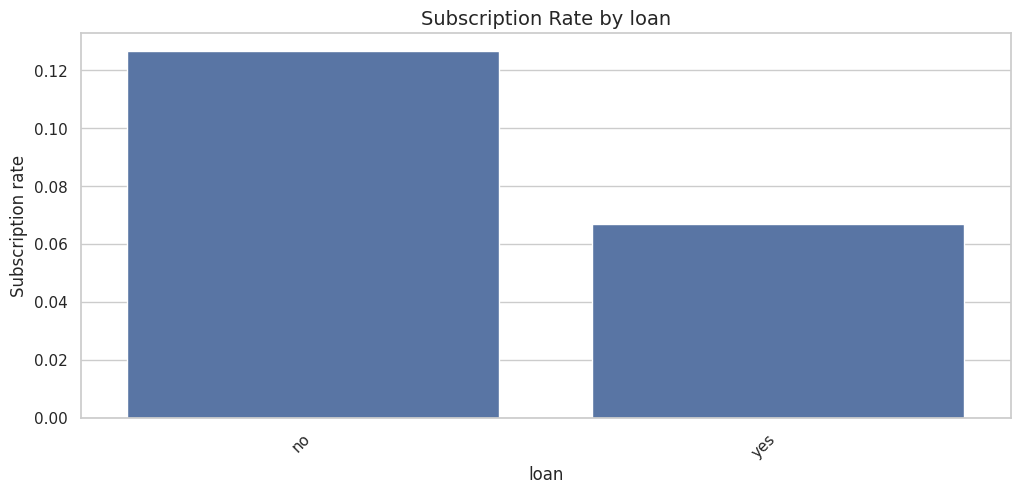

,subscription_rate,count
loan,,
no,0.126557,37967
yes,0.066814,7244


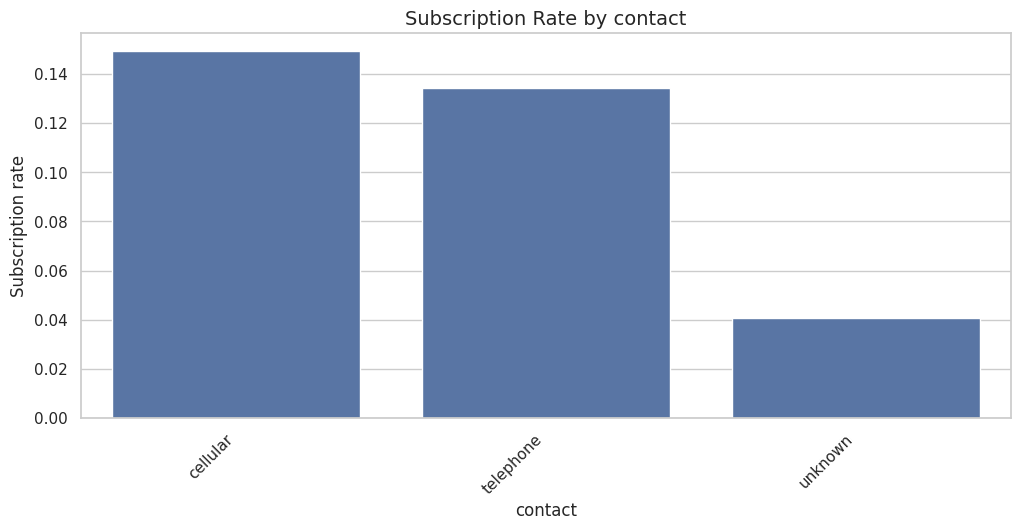

,subscription_rate,count
contact,,
cellular,0.149189,29285
telephone,0.134205,2906
unknown,0.040707,13020


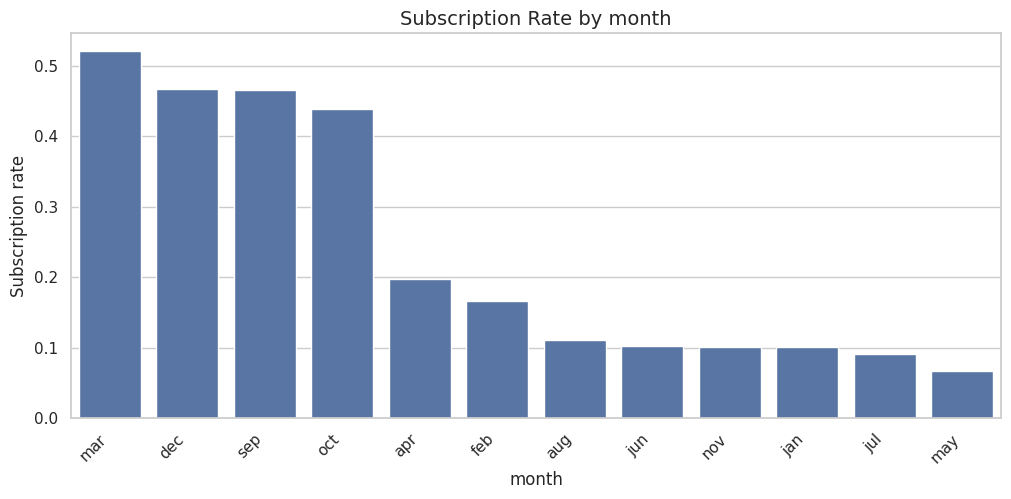

,subscription_rate,count
month,,
mar,0.519916,477
dec,0.467290,214
sep,0.464594,579
oct,0.437669,738
apr,0.196794,2932
feb,0.166478,2649
aug,0.110133,6247
jun,0.102228,5341
nov,0.101511,3970


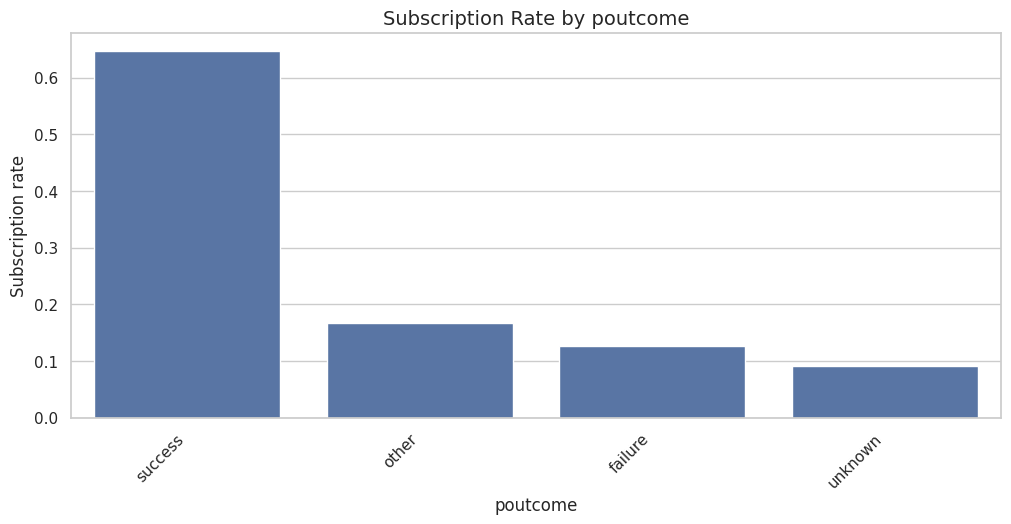

,subscription_rate,count
poutcome,,
success,0.647253,1511
other,0.166848,1840
failure,0.126097,4901
unknown,0.091615,36959


In [24]:
for col in cat_cols:
    plot_subscription_rate_by_category(df, col)

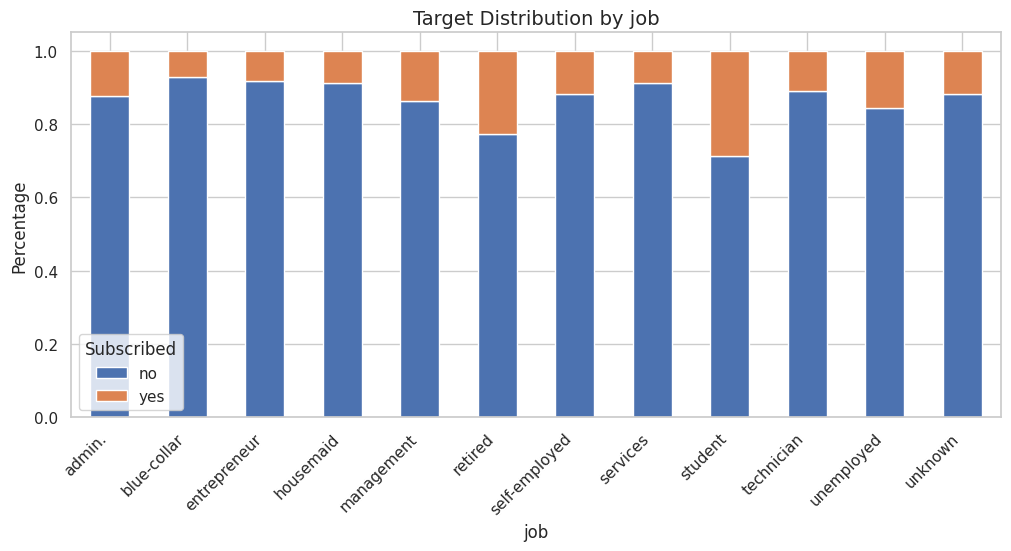

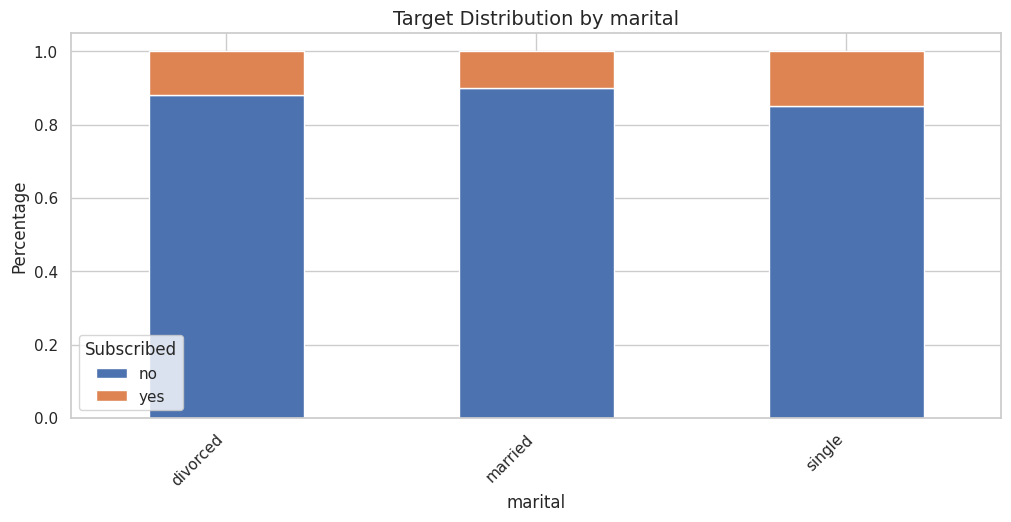

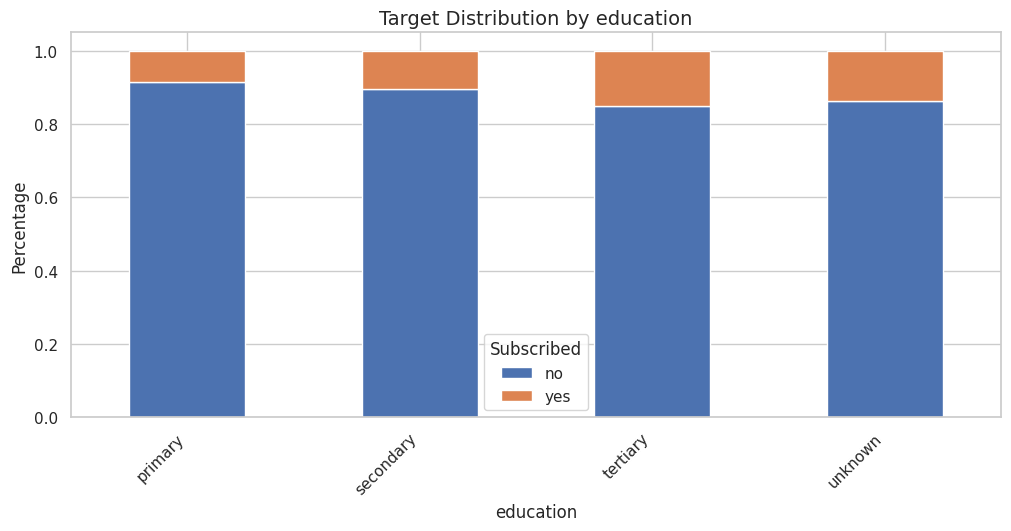

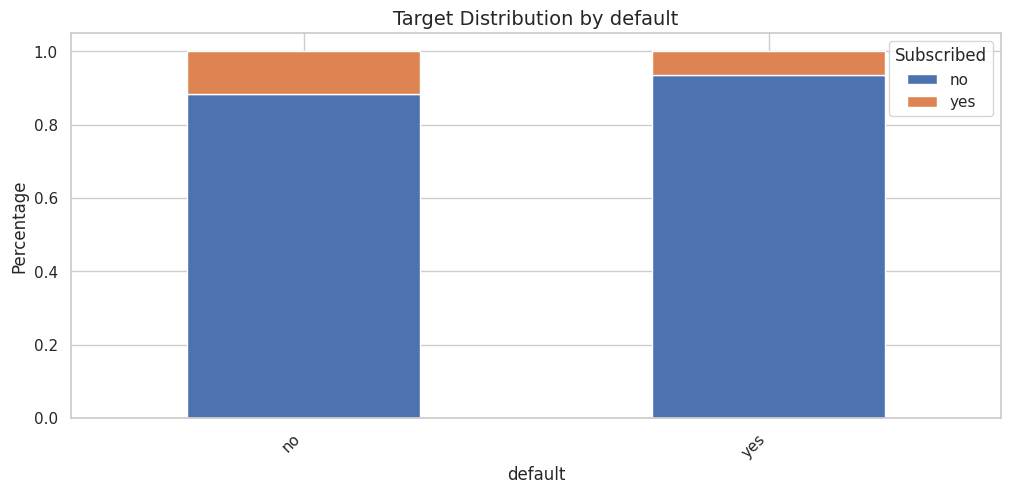

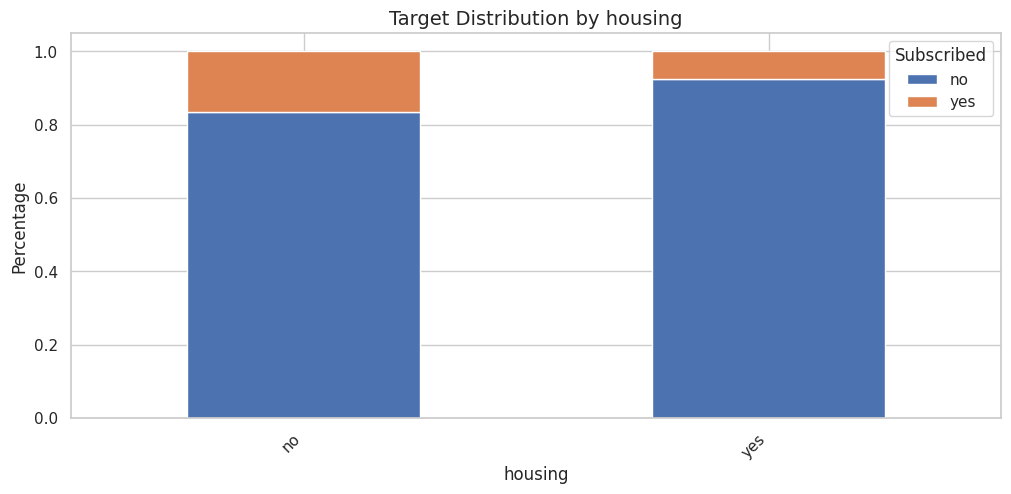

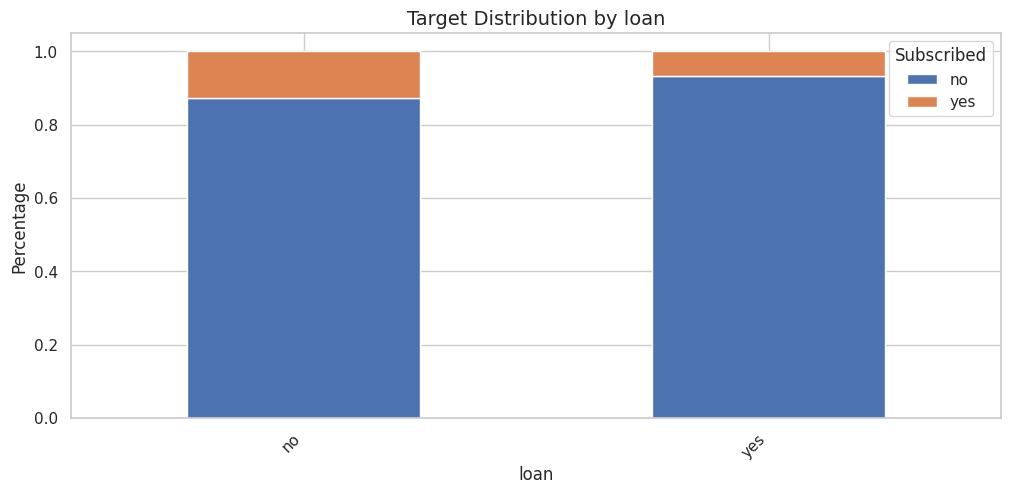

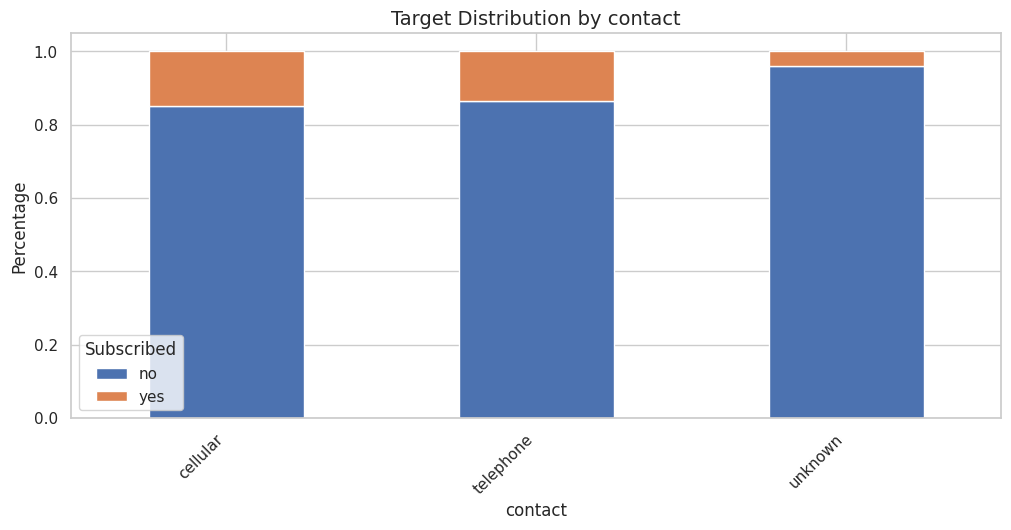

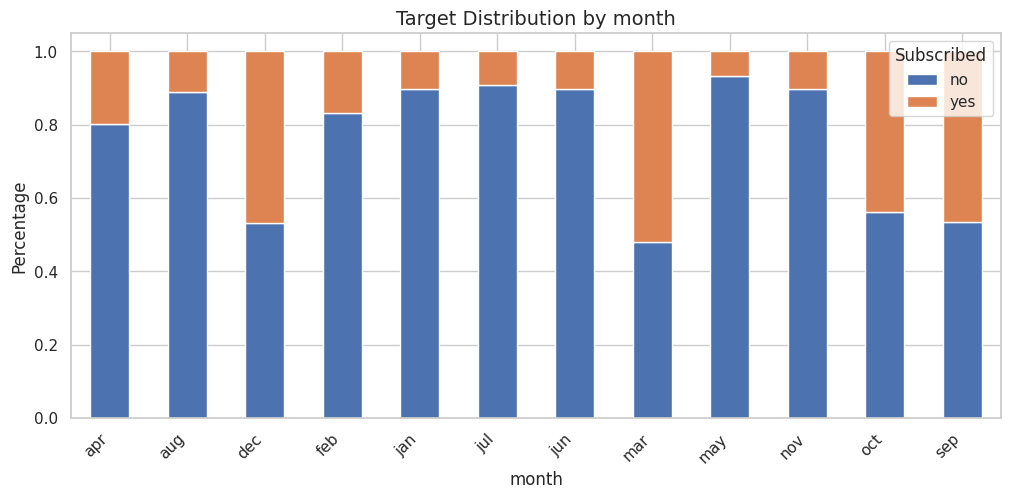

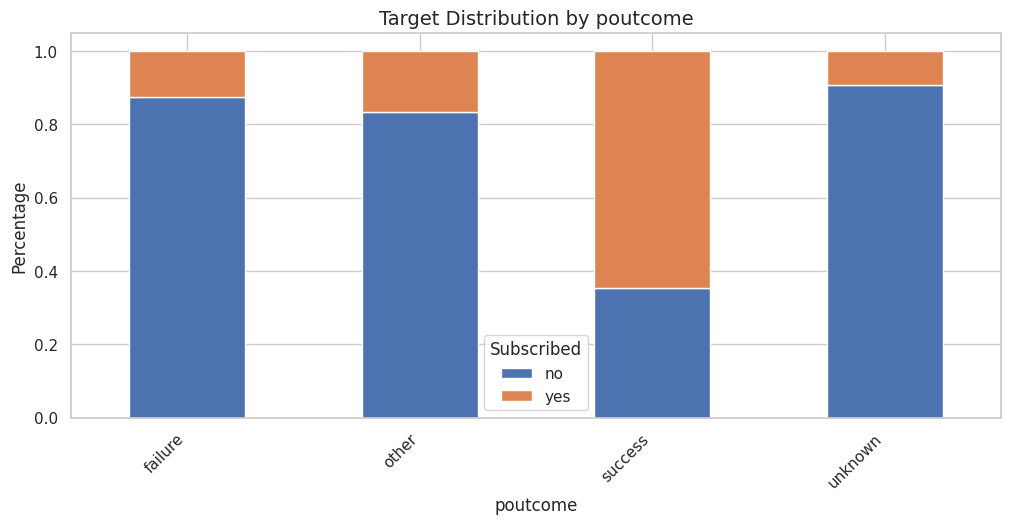

In [25]:
for col in cat_cols:
    crosstab = pd.crosstab(df[col], df["y"], normalize="index")

    crosstab.plot(kind="bar", stacked=True, figsize=(12, 5))
    plt.title(f"Target Distribution by {col}")
    plt.ylabel("Percentage")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Subscribed")
    plt.show()

### Categorical interpretation

Possible comments:

- Some job or education groups may show different subscription rates.
- Previous campaign outcome (`poutcome`) may be informative.
- Contact type and month may capture communication channel and timing effects.
- Categories with `"unknown"` should be monitored because they may show different behavior.

## 9. Cramér's V: categorical association with target

Cramér's V measures the association between categorical variables and the target.  
This gives a more systematic view than visual inspection only.

In [26]:
# ============================================================
# 9. CRAMER'S V ASSOCIATION WITH TARGET
# ============================================================

def cramers_v(x, y):
    # Compute Cramer's V statistic for two categorical variables.
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape

    if min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

cramer_results = {}

for col in cat_cols:
    cramer_results[col] = cramers_v(df[col], df["y"])

cramer_df = (
    pd.DataFrame.from_dict(cramer_results, orient="index", columns=["cramers_v"])
    .sort_values("cramers_v", ascending=False)
)

display(cramer_df)

,cramers_v
poutcome,0.311663
month,0.260237
contact,0.151355
housing,0.139103
job,0.135990
education,0.072695
loan,0.068091
marital,0.065926
default,0.022160


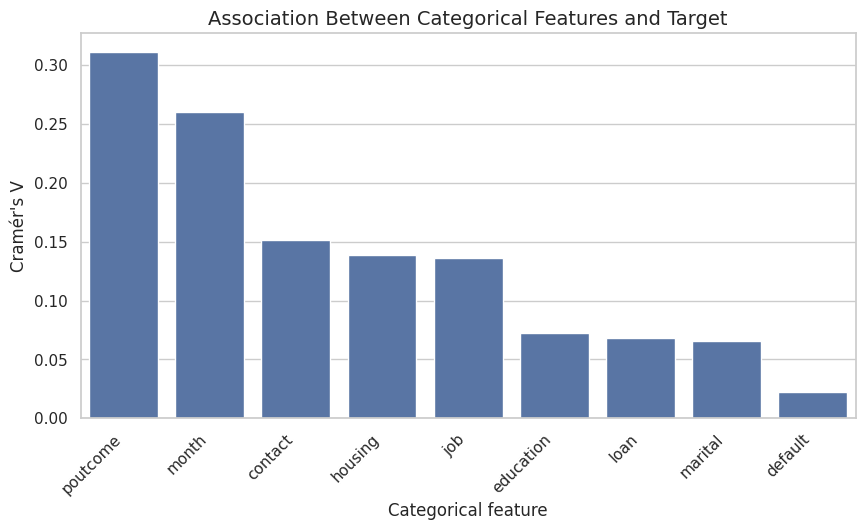

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cramer_df.reset_index(), x="index", y="cramers_v")
plt.title("Association Between Categorical Features and Target")
plt.xlabel("Categorical feature")
plt.ylabel("Cramér's V")
plt.xticks(rotation=45, ha="right")
plt.show()

## 10. Correlation analysis for numerical variables

We compute correlations between numerical variables and with the numeric target.

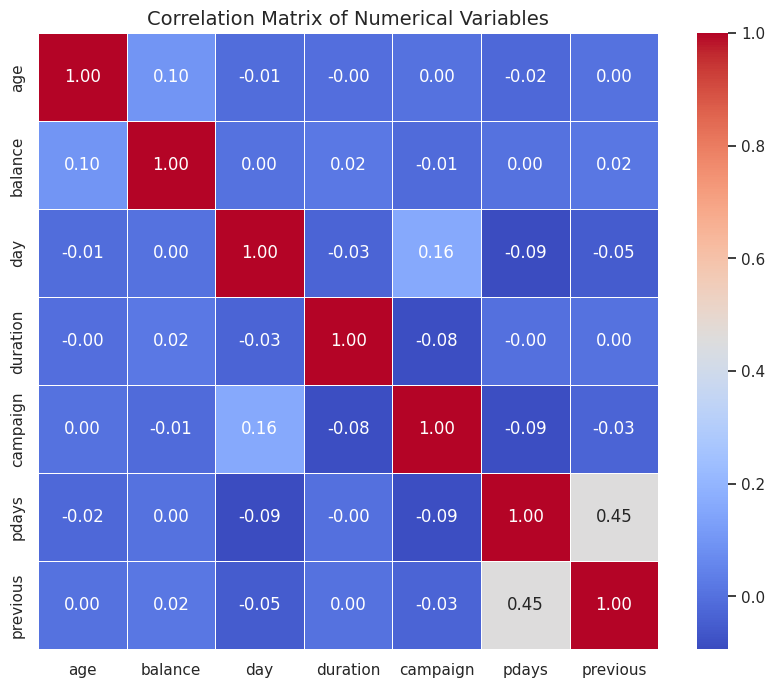

In [28]:
# ============================================================
# 10. CORRELATION ANALYSIS
# ============================================================

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [29]:
df_numeric_target = df.copy()
df_numeric_target["target_binary"] = df_numeric_target["y"].map({"no": 0, "yes": 1})

corr_target = (
    df_numeric_target[num_cols + ["target_binary"]]
    .corr()["target_binary"]
    .drop("target_binary")
    .sort_values(ascending=False)
)

display(corr_target.to_frame("correlation_with_target"))

,correlation_with_target
duration,0.394521
pdays,0.103621
previous,0.093236
balance,0.052838
age,0.025155
day,-0.028348
campaign,-0.073172


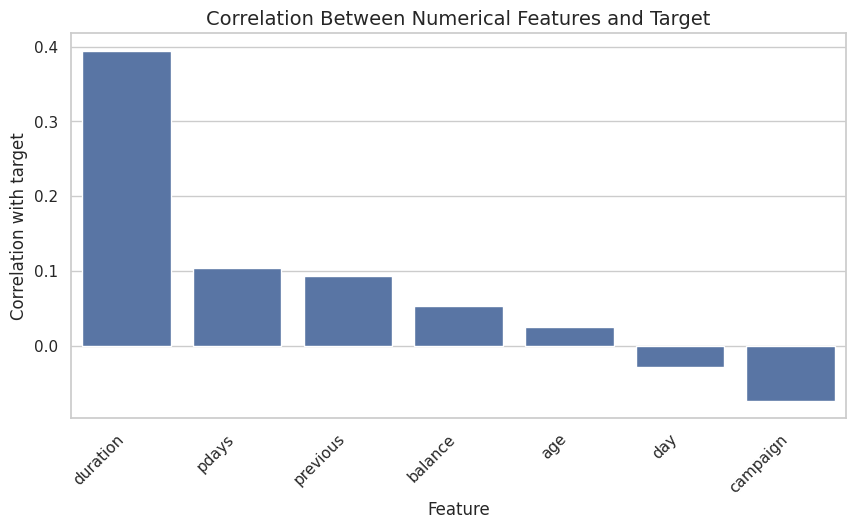

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(x=corr_target.index, y=corr_target.values)
plt.title("Correlation Between Numerical Features and Target")
plt.ylabel("Correlation with target")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.show()

## 11. Business-oriented EDA

This section creates business-readable views:

- subscription rate by month  
- subscription rate by contact type and month  
- subscription rate by previous campaign outcome  
- subscription rate by number of contacts

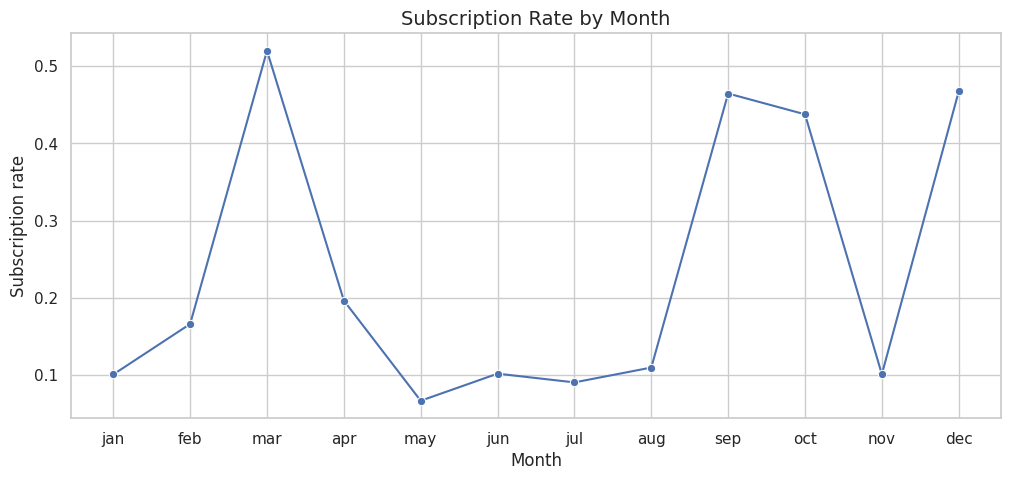

,subscription_rate
month,
jan,0.101212
feb,0.166478
mar,0.519916
apr,0.196794
may,0.067195
jun,0.102228
jul,0.090935
aug,0.110133
sep,0.464594


In [31]:
# ============================================================
# 11. BUSINESS-ORIENTED EDA
# ============================================================

month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

if "month" in df.columns:
    month_rate = (
        df.assign(target_binary=df["y"].map({"no": 0, "yes": 1}))
        .groupby("month")["target_binary"]
        .mean()
        .reindex(month_order)
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(x=month_rate.index, y=month_rate.values, marker="o")
    plt.title("Subscription Rate by Month")
    plt.ylabel("Subscription rate")
    plt.xlabel("Month")
    plt.show()

    display(month_rate.to_frame("subscription_rate"))

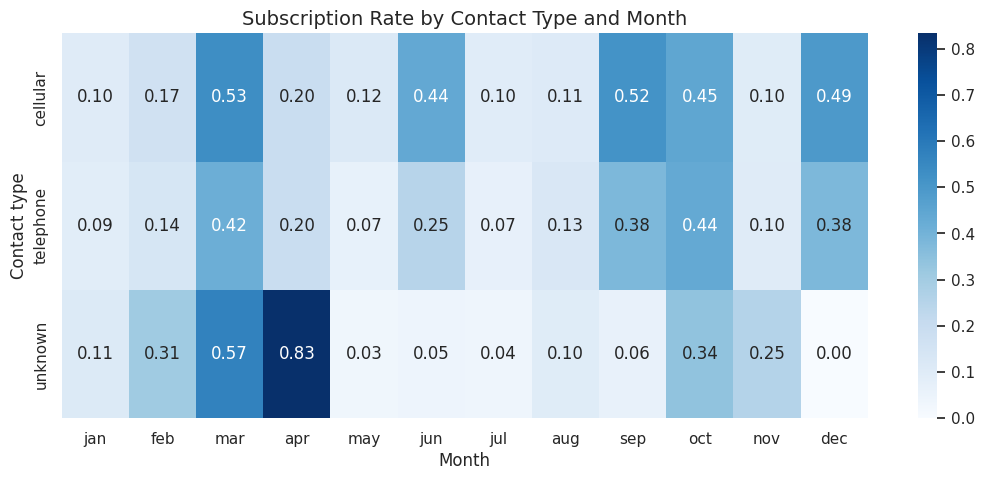

In [32]:
if "month" in df.columns and "contact" in df.columns:
    heatmap_data = (
        df.assign(target_binary=df["y"].map({"no": 0, "yes": 1}))
        .pivot_table(index="contact", columns="month", values="target_binary", aggfunc="mean")
        .reindex(columns=month_order)
    )

    plt.figure(figsize=(13, 5))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Subscription Rate by Contact Type and Month")
    plt.xlabel("Month")
    plt.ylabel("Contact type")
    plt.show()

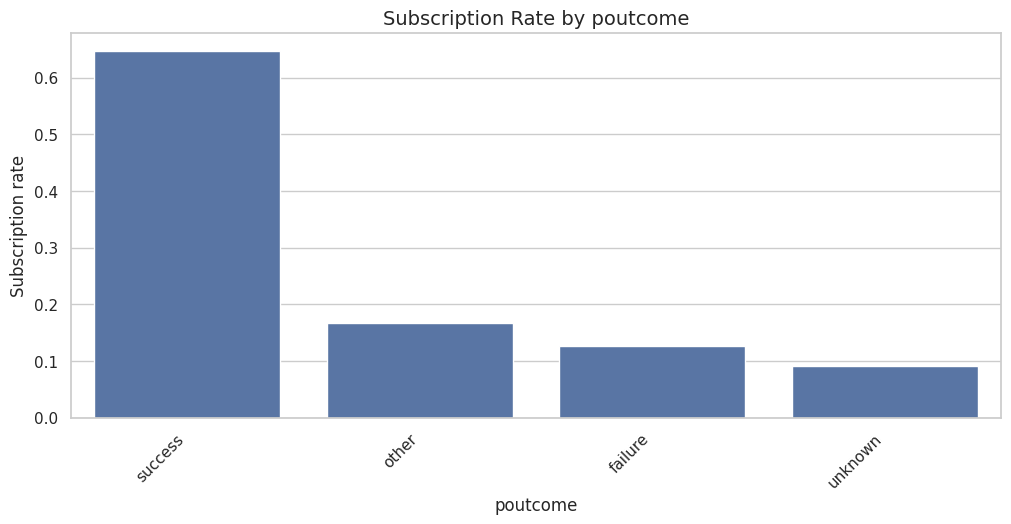

,subscription_rate,count
poutcome,,
success,0.647253,1511
other,0.166848,1840
failure,0.126097,4901
unknown,0.091615,36959


In [33]:
if "poutcome" in df.columns:
    plot_subscription_rate_by_category(df, "poutcome")

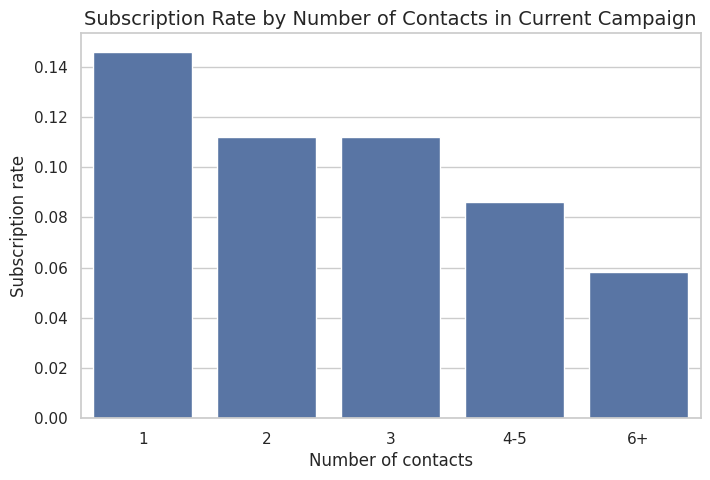

,subscription_rate
campaign_bucket,
1,0.145976
2,0.112035
3,0.111936
4-5,0.086266
6+,0.058094


In [34]:
if "campaign" in df.columns:
    temp = df.copy()
    temp["campaign_bucket"] = pd.cut(
        temp["campaign"],
        bins=[0, 1, 2, 3, 5, np.inf],
        labels=["1", "2", "3", "4-5", "6+"]
    )

    campaign_rate = (
        temp.assign(target_binary=temp["y"].map({"no": 0, "yes": 1}))
        .groupby("campaign_bucket")["target_binary"]
        .mean()
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(x=campaign_rate.index, y=campaign_rate.values)
    plt.title("Subscription Rate by Number of Contacts in Current Campaign")
    plt.xlabel("Number of contacts")
    plt.ylabel("Subscription rate")
    plt.show()

    display(campaign_rate.to_frame("subscription_rate"))

## EDA summary

Complete this after running the notebook.

Suggested structure:

1. **Target distribution**  
   The target variable is ...

2. **Numerical features**  
   Variables such as ... show relevant differences between subscribed and non-subscribed clients.

3. **Categorical features**  
   Variables such as ... appear associated with subscription probability.

4. **Business interpretation**  
   The bank could use these patterns to prioritize clients with higher estimated conversion probability.

5. **Modeling implication**  
   Since both numerical and categorical variables are present, preprocessing requires scaling for Logistic Regression and one-hot encoding for categorical features.

# 12. Data preprocessing

We now prepare the data for modeling.

Steps:

1. Encode target variable  
2. Split into training, validation and test sets  
3. Define preprocessing pipelines  

We use a 60/20/20 split:

- training set: model fitting  
- validation set: model selection and tuning  
- test set: final unbiased evaluation

In [35]:
# ============================================================
# 12. DATA PREPROCESSING
# ============================================================

X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTarget positive rate in each set:")
print("Train:", y_train.mean().round(4))
print("Validation:", y_val.mean().round(4))
print("Test:", y_test.mean().round(4))

Training set: (27126, 16)
Validation set: (9042, 16)
Test set: (9043, 16)

Target positive rate in each set:
Train: 0.117
Validation: 0.117
Test: 0.117


In [37]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# 13. Evaluation functions

Because this is a binary classification problem and the target may be imbalanced, we evaluate:

- Accuracy  
- Balanced Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC  
- PR-AUC

In [38]:
# ============================================================
# 13. EVALUATION FUNCTIONS
# ============================================================

def evaluate_model(model, X_data, y_data, model_name="Model", threshold=0.5):
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_data, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_data, y_pred),
        "precision": precision_score(y_data, y_pred, zero_division=0),
        "recall": recall_score(y_data, y_pred, zero_division=0),
        "f1": f1_score(y_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_data, y_proba),
        "pr_auc": average_precision_score(y_data, y_proba)
    }

    return metrics


def plot_confusion_matrix(model, X_data, y_data, threshold=0.5, title="Confusion Matrix"):
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_data, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def print_classification_report(model, X_data, y_data, threshold=0.5):
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    print(classification_report(y_data, y_pred, target_names=["no", "yes"]))

# 14. Baseline model

Before training real ML models, we create a naive baseline.

This answers:

> Do our ML models actually improve over a trivial prediction rule?

In [39]:
# ============================================================
# 14. BASELINE MODEL
# ============================================================

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("model", baseline_model)
])

baseline_pipeline.fit(X_train, y_train)

baseline_val_metrics = evaluate_model(
    baseline_pipeline,
    X_val,
    y_val,
    model_name="Baseline - Most Frequent"
)

display(pd.DataFrame([baseline_val_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline - Most Frequent,0.5,0.88299,0.5,0.0,0.0,0.0,0.5,0.11701


# 15. Model 1 — Logistic Regression

Logistic Regression is used because it is:

- simple  
- interpretable  
- a strong baseline for binary classification  
- useful for understanding linear effects  

We use `class_weight="balanced"` to compensate for possible class imbalance.

In [40]:
# ============================================================
# 15. LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", logistic_preprocessor),
    ("model", logistic_model)
])

logistic_pipeline.fit(X_train, y_train)

logistic_val_metrics = evaluate_model(
    logistic_pipeline,
    X_val,
    y_val,
    model_name="Logistic Regression"
)

display(pd.DataFrame([logistic_val_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.5,0.843508,0.831852,0.414388,0.816635,0.549793,0.907283,0.543847


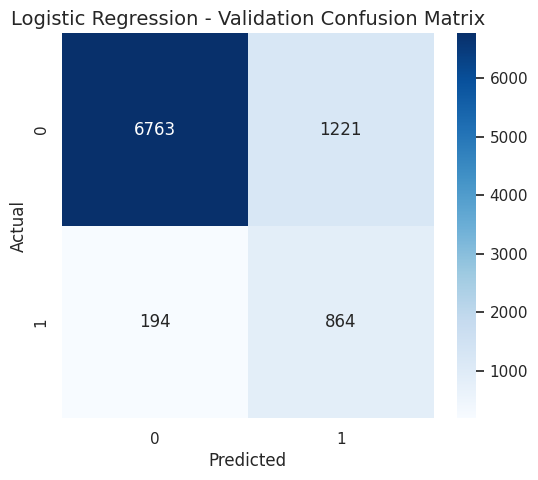

              precision    recall  f1-score   support

          no       0.97      0.85      0.91      7984
         yes       0.41      0.82      0.55      1058

    accuracy                           0.84      9042
   macro avg       0.69      0.83      0.73      9042
weighted avg       0.91      0.84      0.86      9042



In [41]:
plot_confusion_matrix(
    logistic_pipeline,
    X_val,
    y_val,
    title="Logistic Regression - Validation Confusion Matrix"
)

print_classification_report(logistic_pipeline, X_val, y_val)

# 16. Model 2 — Random Forest

Random Forest is used because it can capture:

- non-linear relationships  
- interactions between variables  
- complex customer behavior  

It is an ensemble of decision trees and is often effective on tabular data.

In [42]:
# ============================================================
# 16. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_val_metrics = evaluate_model(
    rf_pipeline,
    X_val,
    y_val,
    model_name="Random Forest"
)

display(pd.DataFrame([rf_val_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.5,0.902676,0.775574,0.580036,0.609641,0.59447,0.928743,0.614651


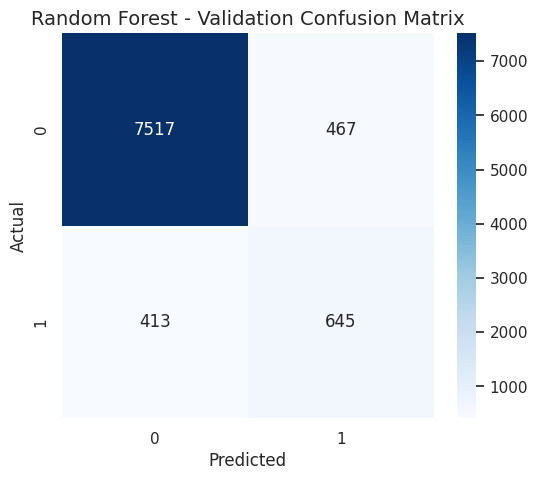

              precision    recall  f1-score   support

          no       0.95      0.94      0.94      7984
         yes       0.58      0.61      0.59      1058

    accuracy                           0.90      9042
   macro avg       0.76      0.78      0.77      9042
weighted avg       0.90      0.90      0.90      9042



In [43]:
plot_confusion_matrix(
    rf_pipeline,
    X_val,
    y_val,
    title="Random Forest - Validation Confusion Matrix"
)

print_classification_report(rf_pipeline, X_val, y_val)

# 17. Model comparison on validation set

The preferred model should not be selected only by accuracy, especially if the target is imbalanced.

In [44]:
# ============================================================
# 17. MODEL COMPARISON
# ============================================================

comparison_val = pd.DataFrame([
    baseline_val_metrics,
    logistic_val_metrics,
    rf_val_metrics
])

display(comparison_val.sort_values("roc_auc", ascending=False))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
2,Random Forest,0.5,0.902676,0.775574,0.580036,0.609641,0.594470,0.928743,0.614651
1,Logistic Regression,0.5,0.843508,0.831852,0.414388,0.816635,0.549793,0.907283,0.543847
0,Baseline - Most Frequent,0.5,0.882990,0.500000,0.000000,0.000000,0.000000,0.500000,0.117010


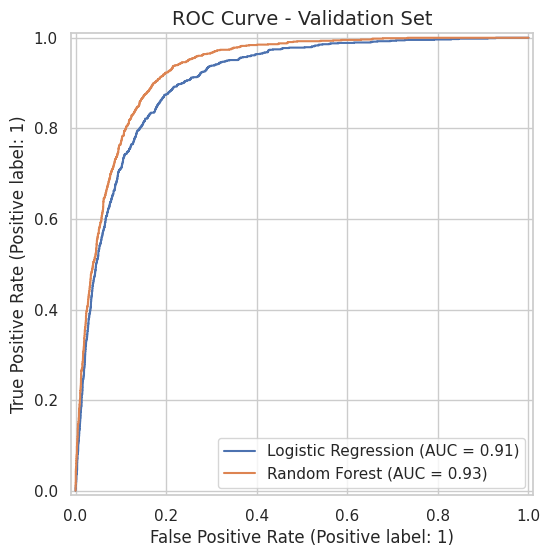

In [45]:
plt.figure(figsize=(8, 6))

for model, name in [
    (logistic_pipeline, "Logistic Regression"),
    (rf_pipeline, "Random Forest")
]:
    RocCurveDisplay.from_estimator(model, X_val, y_val, name=name, ax=plt.gca())

plt.title("ROC Curve - Validation Set")
plt.show()

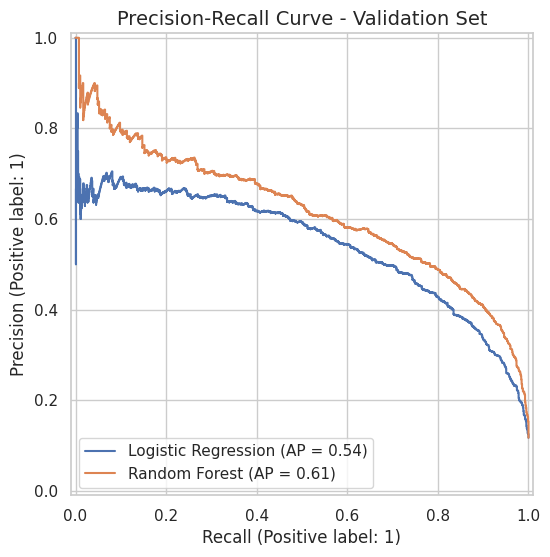

In [46]:
plt.figure(figsize=(8, 6))

for model, name in [
    (logistic_pipeline, "Logistic Regression"),
    (rf_pipeline, "Random Forest")
]:
    PrecisionRecallDisplay.from_estimator(model, X_val, y_val, name=name, ax=plt.gca())

plt.title("Precision-Recall Curve - Validation Set")
plt.show()

### Model comparison interpretation

Complete after running:

- Logistic Regression provides a transparent benchmark.
- Random Forest may achieve better ROC-AUC / PR-AUC due to nonlinear effects.
- If recall is important, threshold optimization may be required.
- If precision is important, the bank can focus calls on fewer clients with higher predicted probability.

# 18. Hyperparameter tuning for Random Forest

We tune the Random Forest to improve generalization and reduce overfitting.

In [47]:
# ============================================================
# 18. RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(rf_grid.best_score_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 500}

Best cross-validation ROC-AUC:
0.9288680681607758


In [48]:
best_rf_pipeline = rf_grid.best_estimator_

best_rf_val_metrics = evaluate_model(
    best_rf_pipeline,
    X_val,
    y_val,
    model_name="Random Forest - Tuned"
)

display(pd.DataFrame([rf_val_metrics, best_rf_val_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.5,0.902676,0.775574,0.580036,0.609641,0.594470,0.928743,0.614651
1,Random Forest - Tuned,0.5,0.903119,0.774185,0.582727,0.605860,0.594069,0.929180,0.615243


# 19. Threshold analysis

The default threshold is 0.5.  
In marketing, the threshold can be adjusted depending on business goals:

- lower threshold: contact more clients, higher recall  
- higher threshold: contact fewer clients, higher precision

In [49]:
# ============================================================
# 19. THRESHOLD ANALYSIS
# ============================================================

def threshold_metrics(model, X_data, y_data, thresholds=np.arange(0.1, 0.91, 0.05)):
    rows = []
    y_proba = model.predict_proba(X_data)[:, 1]

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_data, y_pred),
            "precision": precision_score(y_data, y_pred, zero_division=0),
            "recall": recall_score(y_data, y_pred, zero_division=0),
            "f1": f1_score(y_data, y_pred, zero_division=0),
            "contact_rate": y_pred.mean()
        })

    return pd.DataFrame(rows)

threshold_df = threshold_metrics(best_rf_pipeline, X_val, y_val)
display(threshold_df)

,threshold,accuracy,precision,recall,f1,contact_rate
0,0.10,0.727715,0.296522,0.966919,0.453860,0.381553
1,0.15,0.783455,0.345254,0.948960,0.506304,0.321610
2,0.20,0.813758,0.378399,0.920605,0.536344,0.284672
3,0.25,0.837978,0.411252,0.891304,0.562817,0.253594
4,0.30,0.858660,0.445759,0.854442,0.585872,0.224287
5,0.35,0.873590,0.476376,0.810019,0.599930,0.198960
6,0.40,0.887967,0.514507,0.754253,0.611729,0.171533
7,0.45,0.897810,0.550150,0.694707,0.614035,0.147755
8,0.50,0.903119,0.582727,0.605860,0.594069,0.121655
9,0.55,0.907764,0.625561,0.527410,0.572308,0.098651


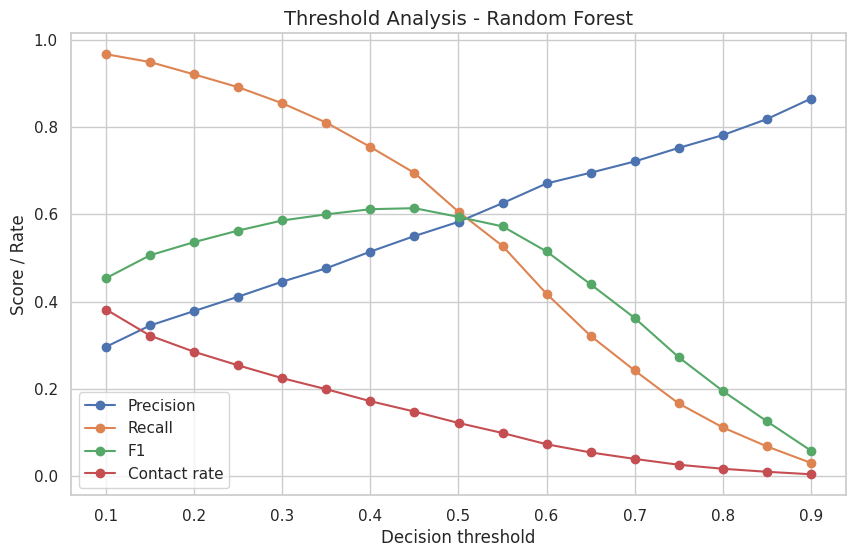

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["threshold"], threshold_df["contact_rate"], marker="o", label="Contact rate")
plt.title("Threshold Analysis - Random Forest")
plt.xlabel("Decision threshold")
plt.ylabel("Score / Rate")
plt.legend()
plt.show()

# 20. Final evaluation on test set

After selecting the preferred model using the validation set, we evaluate it once on the test set.

In [51]:
# ============================================================
# 20. FINAL TEST EVALUATION
# ============================================================

preferred_model = best_rf_pipeline
preferred_model_name = "Random Forest - Tuned"

test_metrics = evaluate_model(
    preferred_model,
    X_test,
    y_test,
    model_name=preferred_model_name
)

display(pd.DataFrame([test_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest - Tuned,0.5,0.90512,0.777366,0.591575,0.610586,0.60093,0.93278,0.633935


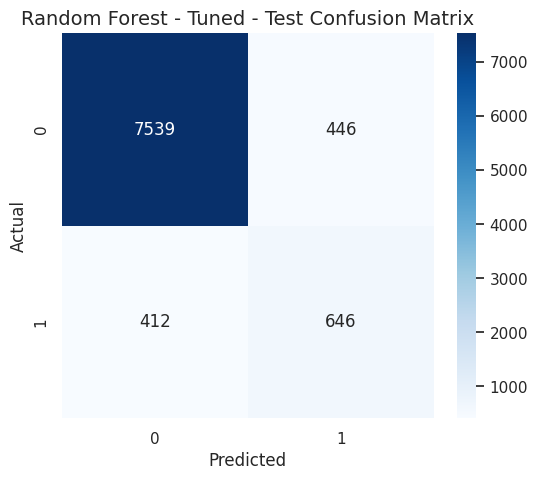

              precision    recall  f1-score   support

          no       0.95      0.94      0.95      7985
         yes       0.59      0.61      0.60      1058

    accuracy                           0.91      9043
   macro avg       0.77      0.78      0.77      9043
weighted avg       0.91      0.91      0.91      9043



In [52]:
plot_confusion_matrix(
    preferred_model,
    X_test,
    y_test,
    title=f"{preferred_model_name} - Test Confusion Matrix"
)

print_classification_report(preferred_model, X_test, y_test)

# 21. Feature selection

The assignment asks to propose a strategy to decrease the number of features and study the impact.

We use Random Forest feature importance to select the most relevant original variables.

In [53]:
# ============================================================
# 21. FEATURE IMPORTANCE AND FEATURE SELECTION
# ============================================================

def get_feature_names_from_preprocessor(preprocessor):
    output_features = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(columns)
        elif transformer == "passthrough":
            names = columns
        else:
            names = columns

        output_features.extend(names)

    return list(output_features)

preprocessor_fitted = preferred_model.named_steps["preprocessor"]
model_fitted = preferred_model.named_steps["model"]

encoded_feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)

rf_importances = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": model_fitted.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importances.head(30))

,feature,importance
3,duration,0.371502
1,balance,0.068643
0,age,0.063962
2,day,0.057558
49,poutcome_success,0.039497
4,campaign,0.029781
5,pdays,0.028924
34,contact_unknown,0.028092
32,contact_cellular,0.020147
6,previous,0.018799


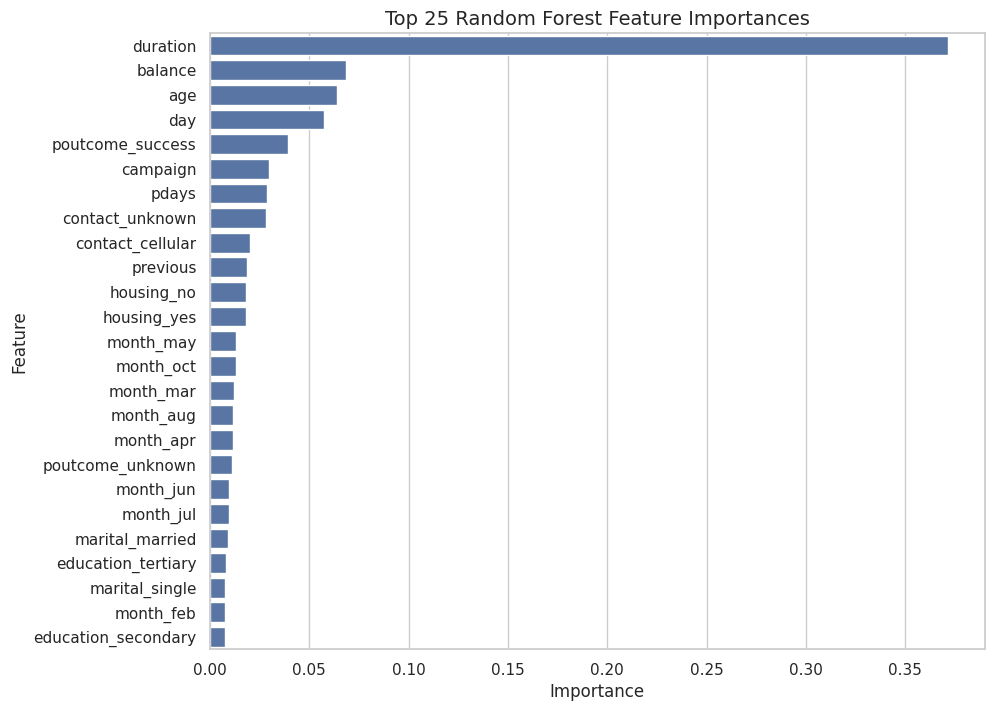

In [54]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=rf_importances.head(25),
    x="importance",
    y="feature"
)
plt.title("Top 25 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [55]:
def map_encoded_to_original(encoded_feature, original_num_features, original_cat_features):
    if encoded_feature in original_num_features:
        return encoded_feature

    for cat in original_cat_features:
        if encoded_feature.startswith(cat + "_"):
            return cat

    return encoded_feature

rf_importances["original_feature"] = rf_importances["feature"].apply(
    lambda x: map_encoded_to_original(x, num_features, cat_features)
)

original_importance = (
    rf_importances.groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(original_importance)

,original_feature,importance
0,duration,0.371502
1,month,0.106615
2,balance,0.068643
3,age,0.063962
4,poutcome,0.059639
5,day,0.057558
6,contact,0.052440
7,job,0.047102
8,housing,0.036484
9,campaign,0.029781


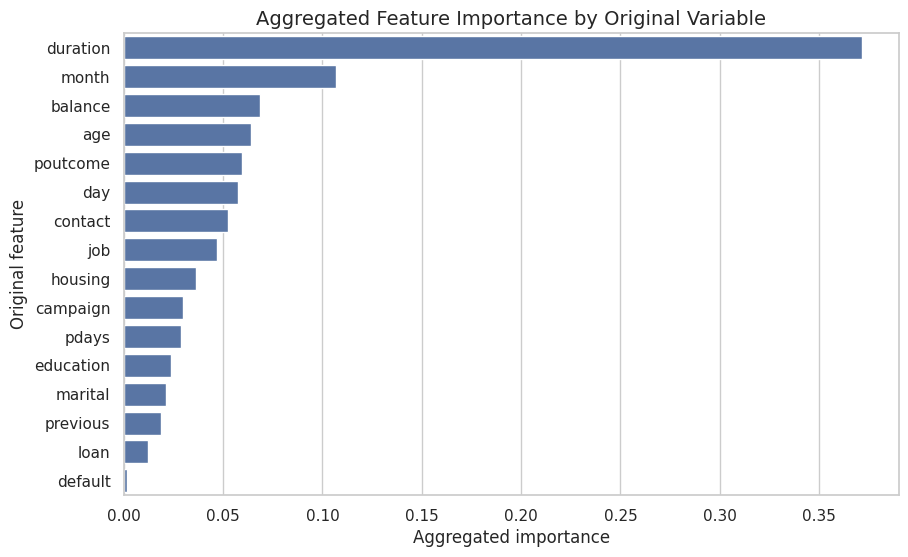

In [56]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=original_importance,
    x="importance",
    y="original_feature"
)
plt.title("Aggregated Feature Importance by Original Variable")
plt.xlabel("Aggregated importance")
plt.ylabel("Original feature")
plt.show()

In [57]:
TOP_K = 10

selected_features = original_importance["original_feature"].head(TOP_K).tolist()
print("Selected features:")
print(selected_features)

Selected features:
['duration', 'month', 'balance', 'age', 'poutcome', 'day', 'contact', 'job', 'housing', 'campaign']


## 22. Retrain model with selected features

We now retrain the preferred model using only selected features and compare performance.

In [58]:
# ============================================================
# 22. RETRAIN WITH SELECTED FEATURES
# ============================================================

X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]

num_features_sel = X_train_sel.select_dtypes(include=np.number).columns.tolist()
cat_features_sel = X_train_sel.select_dtypes(include="object").columns.tolist()

rf_preprocessor_sel = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features_sel),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_sel)
    ]
)

rf_selected_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor_sel),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_selected_pipeline.fit(X_train_sel, y_train)

rf_selected_val_metrics = evaluate_model(
    rf_selected_pipeline,
    X_val_sel,
    y_val,
    model_name=f"Random Forest - Top {TOP_K} Features"
)

feature_selection_comparison = pd.DataFrame([
    best_rf_val_metrics,
    rf_selected_val_metrics
])

display(feature_selection_comparison)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest - Tuned,0.5,0.903119,0.774185,0.582727,0.605860,0.594069,0.929180,0.615243
1,Random Forest - Top 10 Features,0.5,0.899690,0.792332,0.561432,0.652174,0.603411,0.929276,0.608523


In [59]:
rf_selected_test_metrics = evaluate_model(
    rf_selected_pipeline,
    X_test_sel,
    y_test,
    model_name=f"Random Forest - Top {TOP_K} Features"
)

display(pd.DataFrame([test_metrics, rf_selected_test_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest - Tuned,0.5,0.905120,0.777366,0.591575,0.610586,0.600930,0.932780,0.633935
1,Random Forest - Top 10 Features,0.5,0.905894,0.798713,0.587195,0.658790,0.620935,0.933525,0.634711


### Feature selection interpretation

Complete after running:

- The reduced model uses only the top `K` features.
- If performance remains close to the full model, feature selection is successful.
- A simpler model may be easier to explain and deploy.
- If performance drops significantly, removed variables contain useful information.

# 23. Permutation importance

Permutation importance measures how much model performance decreases when each feature is randomly shuffled.

In [60]:
# ============================================================
# 23. PERMUTATION IMPORTANCE
# ============================================================

perm_importance = permutation_importance(
    preferred_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)

,feature,importance_mean,importance_std
11,duration,0.199370,0.005497
10,month,0.050774,0.001399
8,contact,0.028332,0.002844
6,housing,0.013125,0.001650
15,poutcome,0.012885,0.000823
9,day,0.009952,0.000681
13,pdays,0.004479,0.000503
0,age,0.003372,0.000509
5,balance,0.003320,0.000953
7,loan,0.001835,0.000556


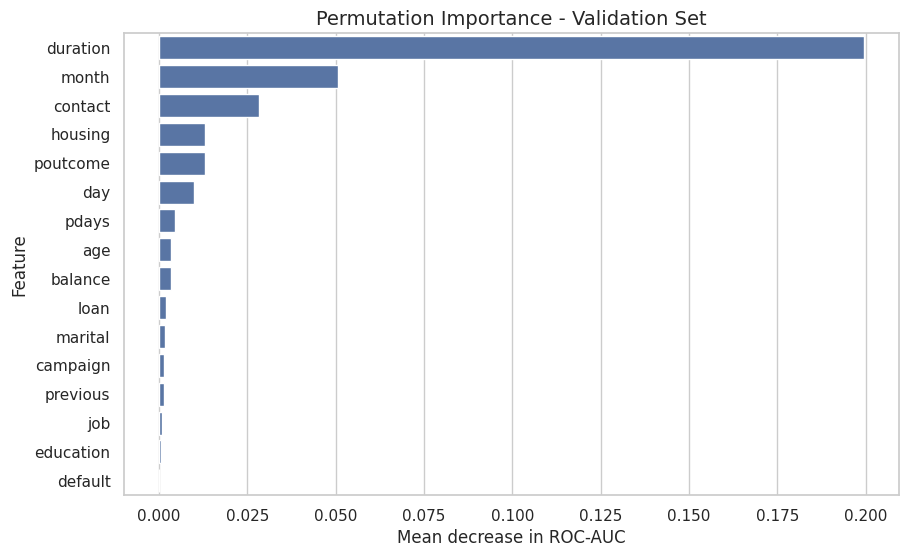

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perm_df,
    x="importance_mean",
    y="feature"
)
plt.title("Permutation Importance - Validation Set")
plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.show()

# 24. SHAP interpretability

SHAP values explain how each feature contributes to model predictions.

They can be used for:

- global interpretability  
- local interpretability

In [ ]:
# ============================================================
# 24. SHAP INTERPRETABILITY
# ============================================================

if not SHAP_AVAILABLE:
    print("SHAP is not available. Install it with: !pip install shap")
else:
    X_val_transformed = preferred_model.named_steps["preprocessor"].transform(X_val)

    if hasattr(X_val_transformed, "toarray"):
        X_val_transformed = X_val_transformed.toarray()

    feature_names = get_feature_names_from_preprocessor(preferred_model.named_steps["preprocessor"])

    sample_size = min(1000, X_val_transformed.shape[0])
    X_shap = X_val_transformed[:sample_size]

    rf_model_only = preferred_model.named_steps["model"]

    explainer = shap.TreeExplainer(rf_model_only)
    shap_values = explainer.shap_values(X_shap)

    print("SHAP values computed.")

In [ ]:
if SHAP_AVAILABLE:
    if isinstance(shap_values, list):
        shap_to_plot = shap_values[1]
    else:
        shap_to_plot = shap_values

    shap.summary_plot(
        shap_to_plot,
        X_shap,
        feature_names=feature_names,
        max_display=20
    )

In [ ]:
if SHAP_AVAILABLE:
    observation_index = 0

    predicted_probability = preferred_model.predict_proba(X_val.iloc[[observation_index]])[0, 1]
    actual_value = y_val.iloc[observation_index]

    print("Observation index:", observation_index)
    print("Predicted probability of subscription:", round(predicted_probability, 4))
    print("Actual target:", actual_value)

    expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

    shap.force_plot(
        expected_value,
        shap_to_plot[observation_index],
        X_shap[observation_index],
        feature_names=feature_names,
        matplotlib=True
    )

### SHAP interpretation

Suggested comments:

- Features with larger absolute SHAP values have stronger impact on predictions.
- Positive SHAP values increase the predicted probability of subscription.
- Negative SHAP values decrease it.
- SHAP helps explain both global model behavior and individual predictions.

# 25. Optional robustness check — model without `duration`

Since `duration` is known only after the phone call, we compare performance without it.

This is methodologically strong because it separates:

- prediction after the call  
- pre-campaign targeting

In [ ]:
# ============================================================
# 25. OPTIONAL ROBUSTNESS CHECK WITHOUT DURATION
# ============================================================

if "duration" in X.columns:
    X_no_duration = X.drop(columns=["duration"])

    X_train_nd, X_temp_nd, y_train_nd, y_temp_nd = train_test_split(
        X_no_duration, y,
        test_size=0.40,
        stratify=y,
        random_state=RANDOM_STATE
    )

    X_val_nd, X_test_nd, y_val_nd, y_test_nd = train_test_split(
        X_temp_nd, y_temp_nd,
        test_size=0.50,
        stratify=y_temp_nd,
        random_state=RANDOM_STATE
    )

    num_nd = X_train_nd.select_dtypes(include=np.number).columns.tolist()
    cat_nd = X_train_nd.select_dtypes(include="object").columns.tolist()

    rf_preprocessor_nd = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_nd),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_nd)
        ]
    )

    rf_no_duration_pipeline = Pipeline(steps=[
        ("preprocessor", rf_preprocessor_nd),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    rf_no_duration_pipeline.fit(X_train_nd, y_train_nd)

    rf_no_duration_metrics = evaluate_model(
        rf_no_duration_pipeline,
        X_val_nd,
        y_val_nd,
        model_name="Random Forest - Without Duration"
    )

    display(pd.DataFrame([
        best_rf_val_metrics,
        rf_no_duration_metrics
    ]))
else:
    print("Variable 'duration' not found in dataset.")

### Duration robustness interpretation

If the model with `duration` performs much better, this confirms that call duration is highly predictive.

However, for a pre-campaign targeting strategy, the model without `duration` may be more realistic.

# 26. Final business conclusions

This section translates technical findings into business insights.

Suggested final structure:

1. **Best model**  
   Which model performed best and why?

2. **Main drivers**  
   Which variables drive subscription probability?

3. **Feature selection result**  
   Can we reduce the number of variables without losing much performance?

4. **Marketing strategy**  
   How can the bank use the model?

5. **Limitations**  
   What should be considered before deployment?

In [ ]:
# ============================================================
# 26. SAVE MAIN RESULTS
# ============================================================

final_results = pd.DataFrame([
    baseline_val_metrics,
    logistic_val_metrics,
    rf_val_metrics,
    best_rf_val_metrics,
    test_metrics,
    rf_selected_test_metrics
])

display(final_results)

## Final written conclusion

Complete after execution.

Example skeleton:

> The Random Forest model achieved the best overall performance, especially in terms of ROC-AUC and PR-AUC.  
> This suggests that customer subscription behavior is not purely linear and may depend on interactions between demographic, financial and campaign-related variables.  
> Feature importance and permutation importance indicate that variables such as `...`, `...`, and `...` are among the main drivers of subscription probability.  
> The feature selection analysis shows that a reduced set of variables can preserve most of the predictive performance, improving model simplicity and interpretability.  
> From a business perspective, the model can support the bank in prioritizing clients with higher subscription probability, reducing unnecessary calls and improving campaign efficiency.